# Proyecto Final — Análisis de Datos
## Predicción de la productividad de operarios en una fábrica textil

**Curso:** Análisis de Datos — ING0039
**Universidad de Montevideo**

**Integrantes del equipo:** Azael Pignanessi · Facundo Sansalone

**Dataset:** *Garments Worker Productivity* (fábrica textil, Bangladesh) — `Tema_11.csv`

---

### Índice

1. [Descripción del problema](#1)
2. [Descripción del conjunto de datos](#2)
3. [Análisis exploratorio de datos (EDA)](#3)
4. [Pretratamiento de datos](#4)
5. [Análisis de datos mediante visualizaciones (PCA)](#5)
6. [Construcción del modelo predictivo](#6)
7. [Resultados obtenidos](#7)
8. [Conclusiones](#8)


<a id="1"></a>
## 1. Descripción del problema

La industria textil de la confección es intensiva en mano de obra y su rentabilidad
depende fuertemente de la **productividad** de los equipos de operarios. Cada equipo
recibe diariamente una **meta de productividad** (`targeted_productivity`) y al cierre
de la jornada se mide la **productividad real alcanzada** (`actual_productivity`).

Para la gerencia de la fábrica resulta clave **entender qué factores del proceso de
producción influyen en la productividad real** y **poder anticiparla** a partir de las
condiciones del día (tamaño del equipo, horas extra, incentivos, tiempos muertos,
trabajo en proceso, etc.).

**Objetivo del proyecto:** construir un modelo predictivo que estime la
`actual_productivity` de un equipo en una jornada dada, a partir de las características
del proceso, e identificar las variables más influyentes. Esto permite a la empresa
detectar tempranamente equipos con riesgo de no cumplir la meta y dirigir acciones
(incentivos, redistribución de carga, reducción de tiempos muertos).

Se trata de un problema de **regresión supervisada**, ya que la variable objetivo es
continua y está acotada al rango [0, 1].


<a id="2"></a>
## 2. Descripción del conjunto de datos

El dataset proviene de una fábrica textil de Bangladesh. Cada fila representa el registro
de **un equipo de trabajo en un día específico**, con información sobre el proceso de
producción y el resultado de productividad obtenido.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 90)

# Carga del dataset crudo (cada fila = un equipo en un día)
df = pd.read_csv('Tema_11.csv')
print('Dataset cargado.')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Dataset cargado.
Dimensiones: 1207 filas x 15 columnas


El dataset tiene **15 variables**, que agrupamos en tres roles: **contexto temporal**,
**variables predictoras** y la **variable objetivo** (`actual_productivity`).

In [2]:
descripcion = pd.DataFrame({
    'Variable': ['date','quarter','department','day','team',
                 'targeted_productivity','smv','wip','over_time','incentive',
                 'idle_time','idle_men','no_of_style_change','no_of_workers','actual_productivity'],
    'Tipo': ['Fecha','Categorica','Categorica','Categorica','Discreta',
             'Continua','Continua','Continua','Continua','Continua',
             'Continua','Discreta','Discreta','Continua','Continua'],
    'Rol': ['Contexto','Contexto','Predictora','Predictora','Predictora',
            'Predictora','Predictora','Predictora','Predictora','Predictora',
            'Predictora','Predictora','Predictora','Predictora','OBJETIVO'],
    'Descripcion': [
        'Fecha del registro (MM/DD/YYYY)',
        'Porcion del mes: Quarter1 a Quarter4',
        'Departamento: sewing (costura) o finishing (acabado)',
        'Dia de la semana del registro',
        'Numero del equipo de trabajo (1-12)',
        'Meta de productividad asignada por la autoridad (0-1)',
        'Standard Minute Value: tiempo estandar para la tarea (min)',
        'Work In Progress: unidades iniciadas pero no terminadas',
        'Horas extra trabajadas por el equipo (minutos)',
        'Incentivo economico otorgado al equipo (BDT)',
        'Tiempo de interrupcion de la produccion (minutos)',
        'Trabajadores inactivos durante interrupciones',
        'Cantidad de cambios en el diseno del producto',
        'Total de trabajadores en el equipo',
        'Productividad real alcanzada por el equipo (0-1) -- OBJETIVO'
    ]
})
descripcion

,Variable,Tipo,Rol,Descripcion
0,date,Fecha,Contexto,Fecha del registro (MM/DD/YYYY)
1,quarter,Categorica,Contexto,Porcion del mes: Quarter1 a Quarter4
2,department,Categorica,Predictora,Departamento: sewing (costura) o finishing (acabado)
3,day,Categorica,Predictora,Dia de la semana del registro
4,team,Discreta,Predictora,Numero del equipo de trabajo (1-12)
5,targeted_productivity,Continua,Predictora,Meta de productividad asignada por la autoridad (0-1)
6,smv,Continua,Predictora,Standard Minute Value: tiempo estandar para la tarea (min)
7,wip,Continua,Predictora,Work In Progress: unidades iniciadas pero no terminadas
8,over_time,Continua,Predictora,Horas extra trabajadas por el equipo (minutos)
9,incentive,Continua,Predictora,Incentivo economico otorgado al equipo (BDT)


<a id="3"></a>
## 3. Análisis exploratorio de datos (EDA)

Exploramos dimensiones, tipos de dato, datos faltantes y duplicados, distribuciones e
inconsistencias, antes de cualquier limpieza.

### 3a. Cantidad de filas y columnas

In [3]:
filas, columnas = df.shape
print(f'Filas:    {filas}')
print(f'Columnas: {columnas}')
print()
print('Tipos de dato (object=texto, float64=decimal):')
print(df.dtypes)

Filas:    1207
Columnas: 15

Tipos de dato (object=texto, float64=decimal):
date                      object
quarter                   object
department                object
day                       object
team                      object
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                float64
incentive                float64
idle_time                float64
idle_men                 float64
no_of_style_change       float64
no_of_workers            float64
actual_productivity      float64
dtype: object


### 3b. Primeras filas y estadísticas descriptivas

In [4]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1.0,0.75,3.94,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,NaN,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6.0,0.80,25.90,NaN,1920.0,50.0,0.0,0.0,0.0,56.0,NaN


In [5]:
df.describe()

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1146.000000,1148.000000,668.000000,1149.000000,1147.000000,1146.000000,1147.000000,1147.000000,1147.000000,1147.000000
mean,0.728988,20.671272,1202.133234,5862.654482,38.871840,0.762653,0.326940,0.151700,34.598518,0.852642
std,0.099195,55.051234,1866.755181,13146.200215,163.488076,12.988774,3.034473,0.429704,22.189488,1.122498
min,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,0.700000,3.940000,783.750000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650899
50%,0.750000,15.260000,1043.000000,4080.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.779792
75%,0.800000,24.260000,1256.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850413
max,0.800000,545.600000,23122.000000,129600.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,11.204375


### 3c. Datos faltantes y duplicados

In [6]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Valores faltantes': nulos, 'Porcentaje (%)': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Valores faltantes'] > 0]\
                .sort_values('Porcentaje (%)', ascending=False)
print('=== Datos faltantes por columna ===')
print(resumen_nulos)
print(f'\nTotal celdas faltantes: {nulos.sum()}')

=== Datos faltantes por columna ===
                       Valores faltantes  Porcentaje (%)
wip                                  539           44.66
date                                  62            5.14
day                                   61            5.05
targeted_productivity                 61            5.05
idle_time                             61            5.05
quarter                               60            4.97
department                            60            4.97
incentive                             60            4.97
idle_men                              60            4.97
no_of_style_change                    60            4.97
no_of_workers                         60            4.97
actual_productivity                   60            4.97
team                                  59            4.89
smv                                   59            4.89
over_time                             58            4.81

Total celdas faltantes: 1380


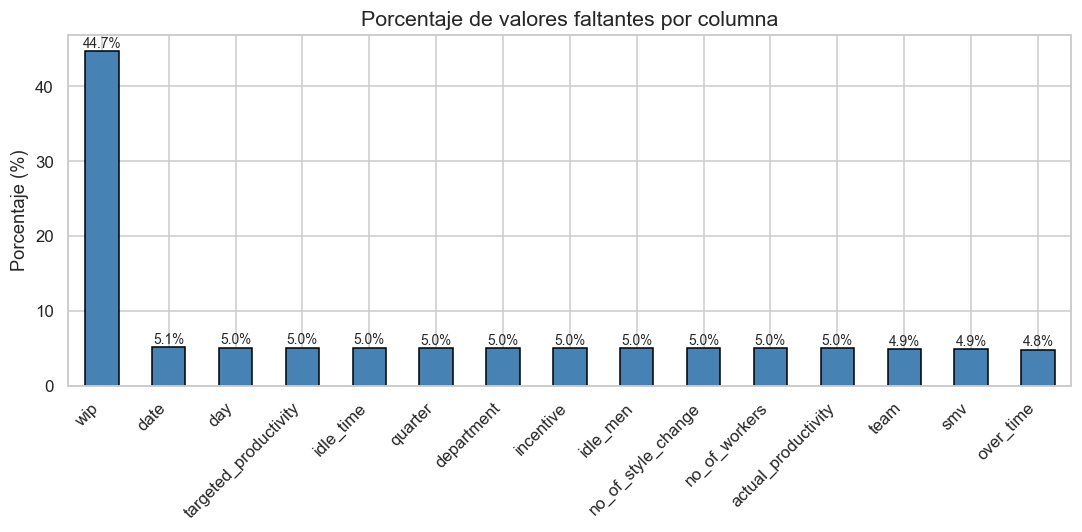

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
resumen_nulos['Porcentaje (%)'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Porcentaje de valores faltantes por columna', fontsize=14)
ax.set_ylabel('Porcentaje (%)')
ax.set_xticklabels(resumen_nulos.index, rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.1),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
n_dup = df.duplicated().sum()
pct_dup = round(n_dup / len(df) * 100, 2)
print(f'Filas duplicadas: {n_dup} ({pct_dup}% del total)')

Filas duplicadas: 10 (0.83% del total)


### 3d. Posibles motivos de los datos faltantes

- **Estructural**: no aplica en ese contexto (ej. `wip` en *finishing*).
- **Derivable**: recuperable desde otra columna (ej. `day` desde `date`).
- **Error de registro**: debería existir pero no fue cargado.
- **Posible cero**: el faltante equivale a la ausencia del fenómeno.

In [9]:
temp = df.copy()
temp['department'] = temp['department'].str.strip()
print('Nulos de wip por departamento:')
print(temp.groupby('department')['wip'].agg(
    total='count',
    faltantes=lambda x: x.isnull().sum(),
    pct=lambda x: f'{x.isnull().mean()*100:.1f}%'
))
print('\nConclusion: los nulos de wip son casi exclusivos de finishing,')
print('donde no hay produccion intermedia por definicion del flujo.')

Nulos de wip por departamento:
            total  faltantes     pct
department                          
finishing       0        477  100.0%
sweing        642         28    4.2%

Conclusion: los nulos de wip son casi exclusivos de finishing,
donde no hay produccion intermedia por definicion del flujo.


In [10]:
motivos = pd.DataFrame([
    ('wip',                   'Estructural',    'En finishing no hay WIP. En sewing: error de registro.'),
    ('date',                  'Error registro', 'Fecha no ingresada. Impide derivar quarter y day.'),
    ('quarter',               'Derivable',      'Calculable desde date (semana del mes).'),
    ('day',                   'Derivable',      'Calculable con pandas desde date.'),
    ('department',            'Error registro', 'Campo obligatorio. Sin el, no se clasifica el registro.'),
    ('targeted_productivity', 'Error registro', 'Meta no registrada. Imputable con mediana del dpto/dia.'),
    ('incentive',             'Posible cero',   'Sin incentivo ese dia; nulo equivale a 0.'),
    ('idle_time',             'Posible cero',   'Sin interrupcion de produccion; nulo equivale a 0.'),
    ('idle_men',              'Posible cero',   'Sin inactividad; nulo equivale a 0.'),
    ('no_of_style_change',    'Posible cero',   'Sin cambios de estilo; nulo equivale a 0.'),
    ('no_of_workers',         'Error registro', 'Siempre debe existir. Imputable con mediana del equipo.'),
    ('actual_productivity',   'Sin medicion',   'Variable objetivo no medida. No imputable: fila se elimina.'),
], columns=['Columna', 'Tipo de faltante', 'Motivo probable'])
motivos[motivos['Columna'].isin(resumen_nulos.index)]

,Columna,Tipo de faltante,Motivo probable
0,wip,Estructural,En finishing no hay WIP. En sewing: error de registro.
1,date,Error registro,Fecha no ingresada. Impide derivar quarter y day.
2,quarter,Derivable,Calculable desde date (semana del mes).
3,day,Derivable,Calculable con pandas desde date.
4,department,Error registro,"Campo obligatorio. Sin el, no se clasifica el registro."
5,targeted_productivity,Error registro,Meta no registrada. Imputable con mediana del dpto/dia.
6,incentive,Posible cero,Sin incentivo ese dia; nulo equivale a 0.
7,idle_time,Posible cero,Sin interrupcion de produccion; nulo equivale a 0.
8,idle_men,Posible cero,Sin inactividad; nulo equivale a 0.
9,no_of_style_change,Posible cero,Sin cambios de estilo; nulo equivale a 0.


### 3e. Valores únicos de variables discretas y categóricas

In [11]:
vars_discretas = ['quarter', 'department', 'day', 'team', 'no_of_style_change', 'idle_men']
for col in vars_discretas:
    conteo = df[col].value_counts(dropna=True).sort_index()
    print(f'--- {col} ({len(conteo)} valores unicos) ---')
    print(conteo.to_frame(name='Frecuencia').T)
    print()

--- quarter (5 valores unicos) ---
quarter     Quarter1  Quarter2  Quarter3  Quarter4  Quarter5
Frecuencia       339       320       203       246        39

--- department (3 valores unicos) ---
department  finishing  finishing   sweing
Frecuencia        233         244     670

--- day (6 valores unicos) ---
day         Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
Frecuencia     190       177     194       190      191        204

--- team (13 valores unicos) ---
team        1.0  10.0  11.0  12.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0  \
Frecuencia   99    96    84    94   99   87  103   84   96   90  106   98   

team        invalid_value  
Frecuencia             12  

--- no_of_style_change (3 valores unicos) ---
no_of_style_change   0.0  1.0  2.0
Frecuencia          1005  110   32

--- idle_men (9 valores unicos) ---
idle_men    0.0   10.0  15.0  20.0  25.0  30.0  35.0  40.0  45.0
Frecuencia  1131     3     3     3     1     2     2     1     1



### 3f. Distribuciones (histogramas, boxplots y correlaciones)

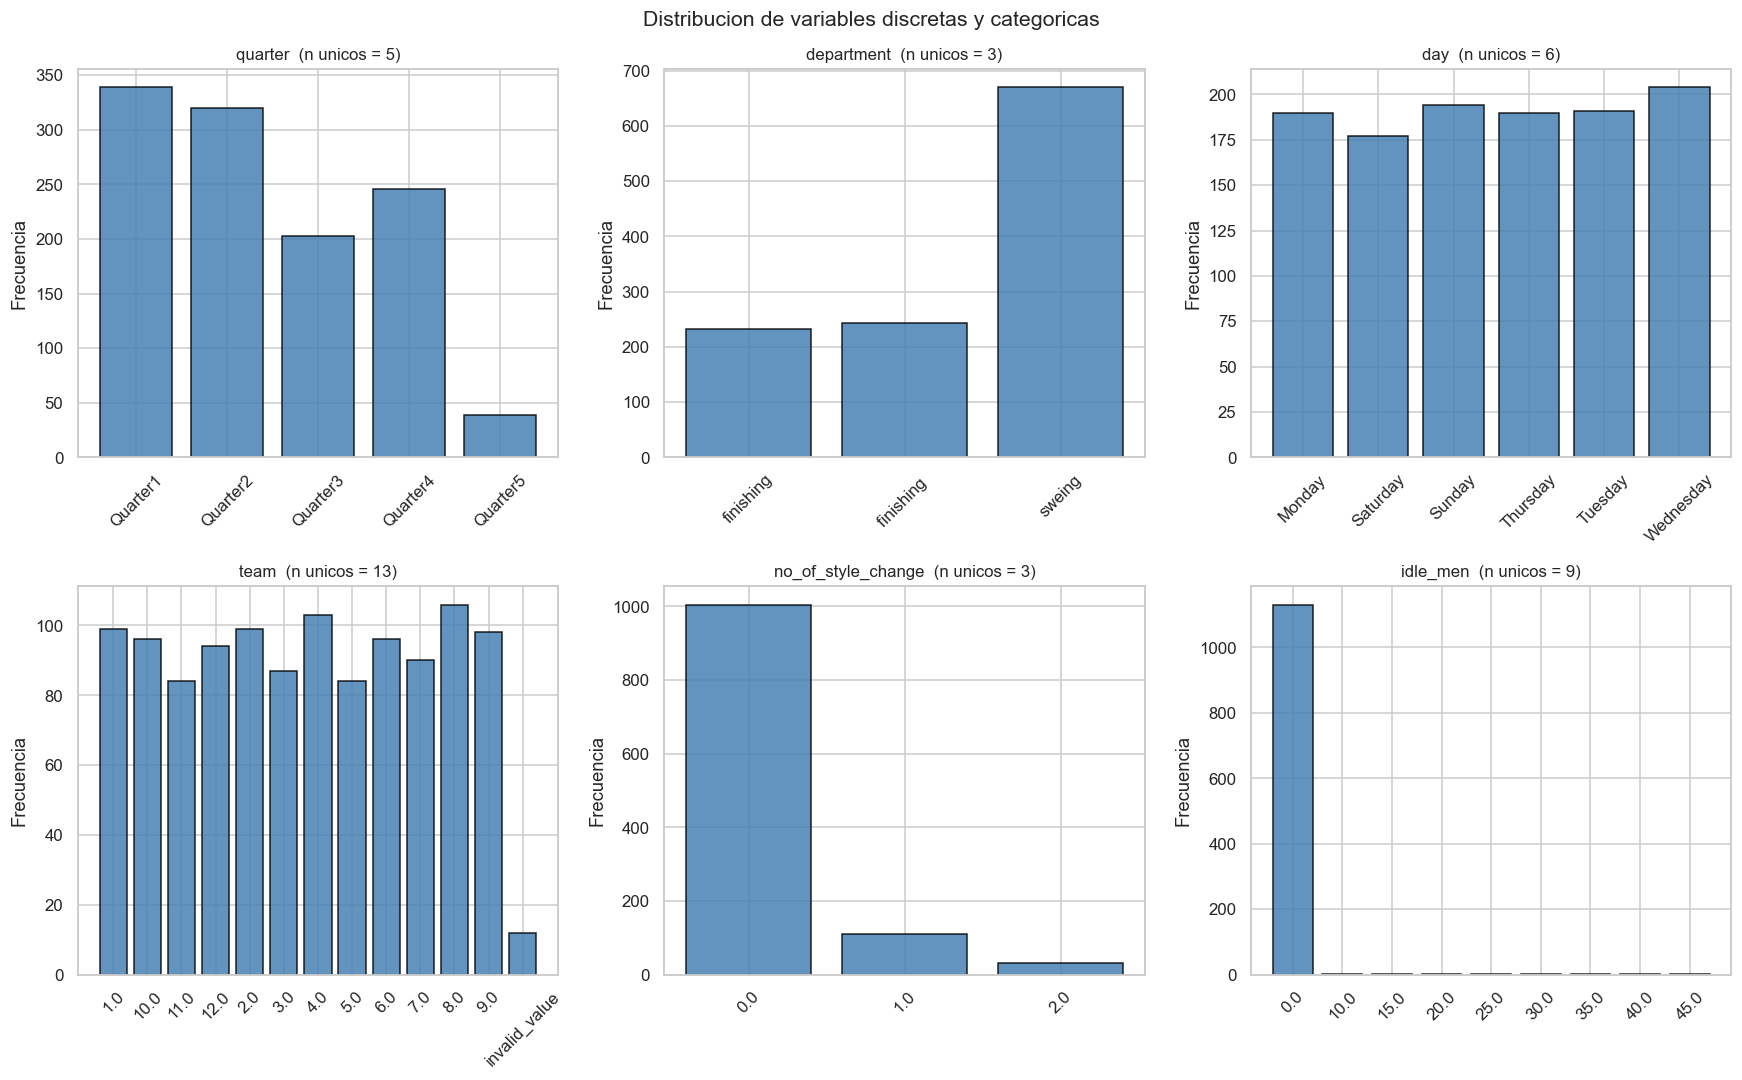

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(vars_discretas):
    conteo = df[col].value_counts().sort_index()
    axes[i].bar(conteo.index.astype(str), conteo.values,
                color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col}  (n unicos = {df[col].nunique()})', fontsize=11)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Distribucion de variables discretas y categoricas', fontsize=14)
plt.tight_layout()
plt.show()

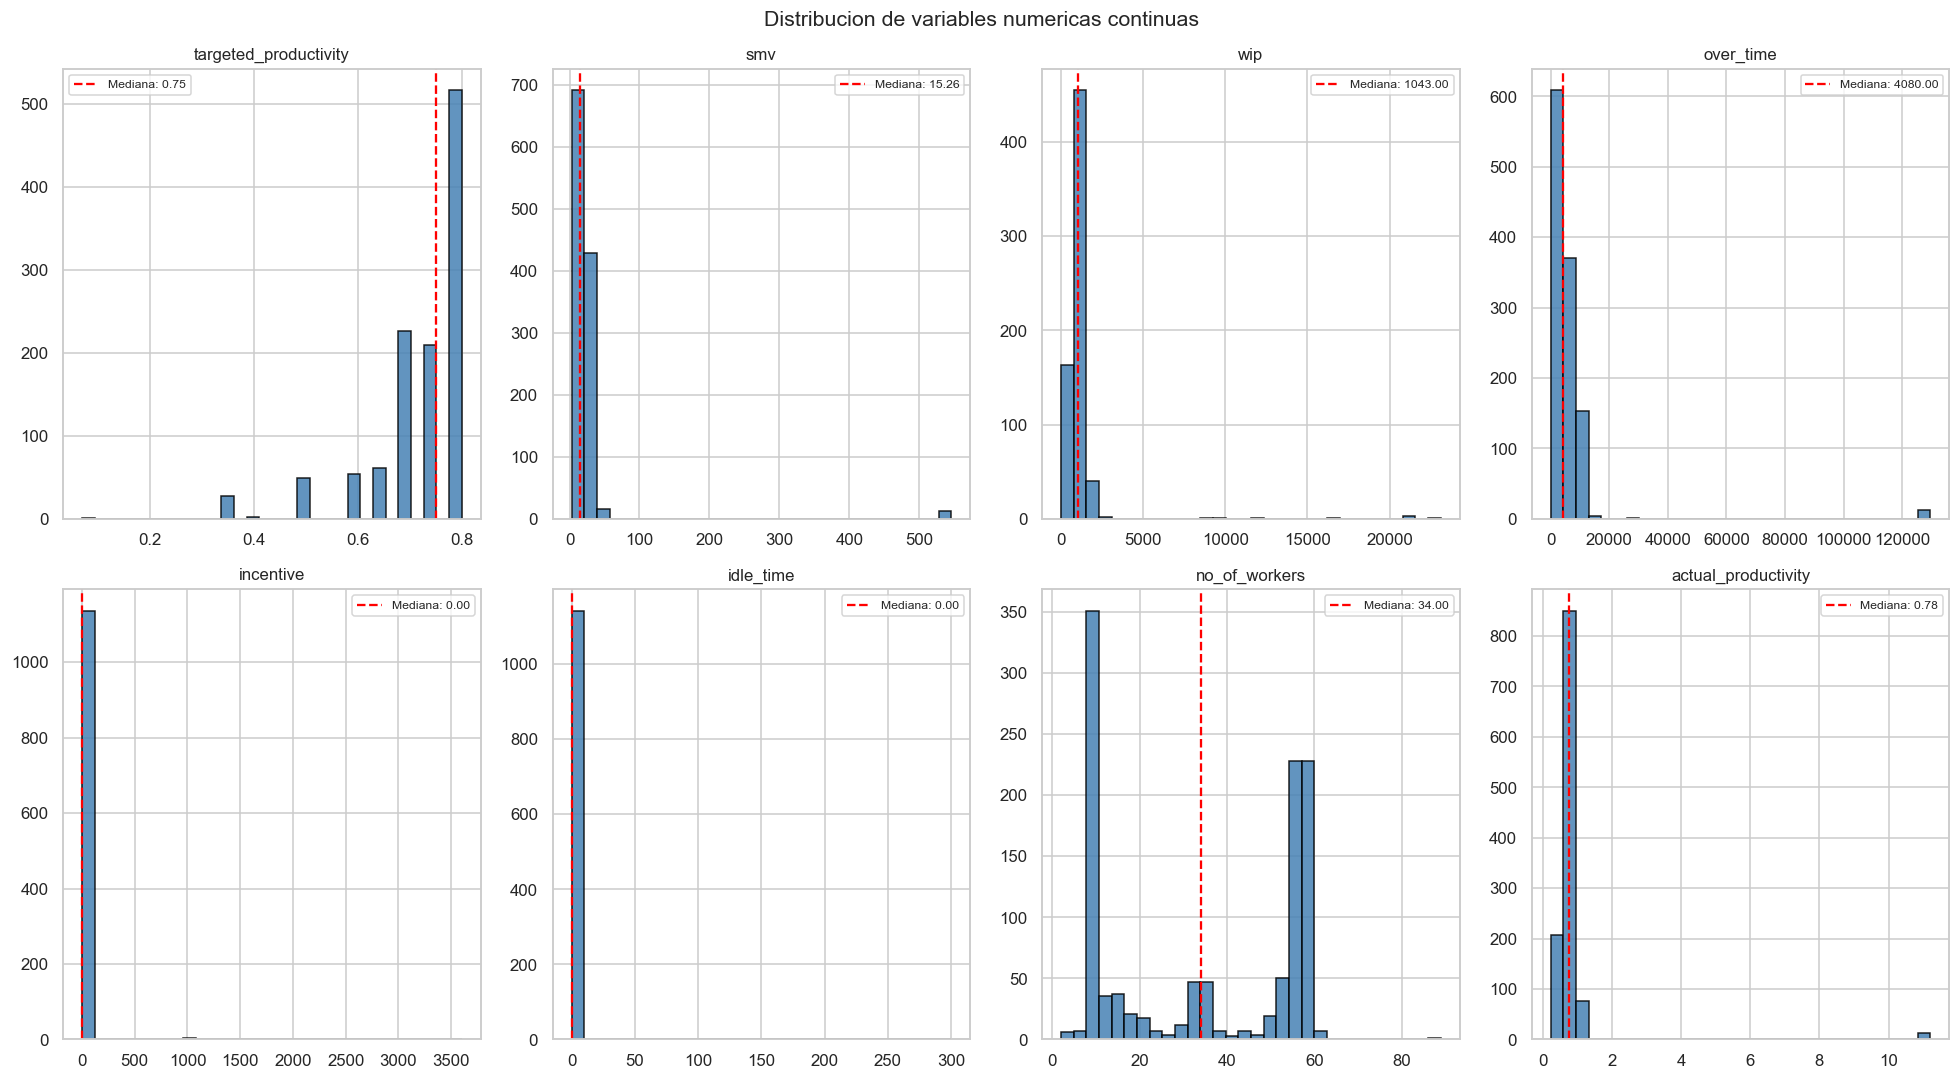

In [13]:
vars_continuas = ['targeted_productivity','smv','wip','over_time',
                  'incentive','idle_time','no_of_workers','actual_productivity']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(vars_continuas):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].axvline(data.median(), color='red', linestyle='--', lw=1.5,
                    label=f'Mediana: {data.median():.2f}')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
plt.suptitle('Distribucion de variables numericas continuas', fontsize=14)
plt.tight_layout()
plt.show()

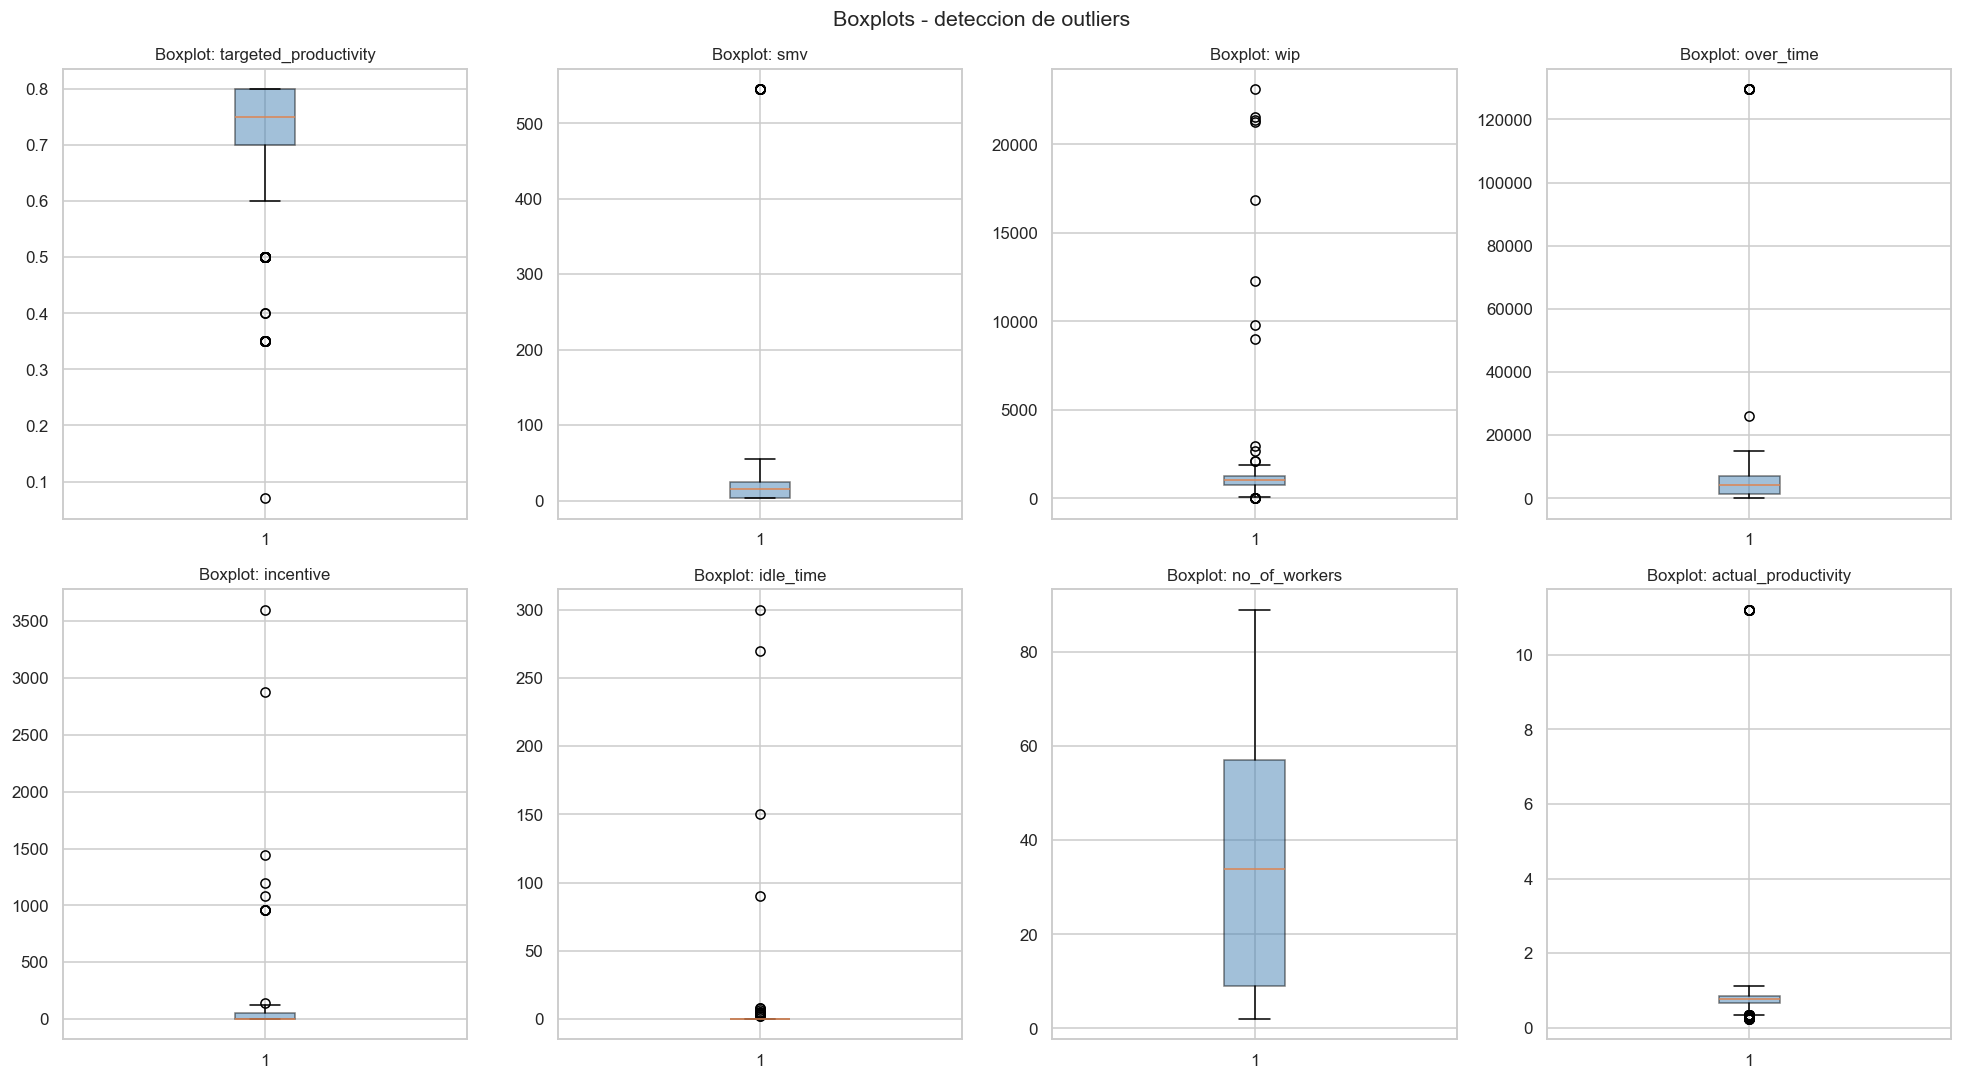

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(vars_continuas):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)
plt.suptitle('Boxplots - deteccion de outliers', fontsize=14)
plt.tight_layout()
plt.show()

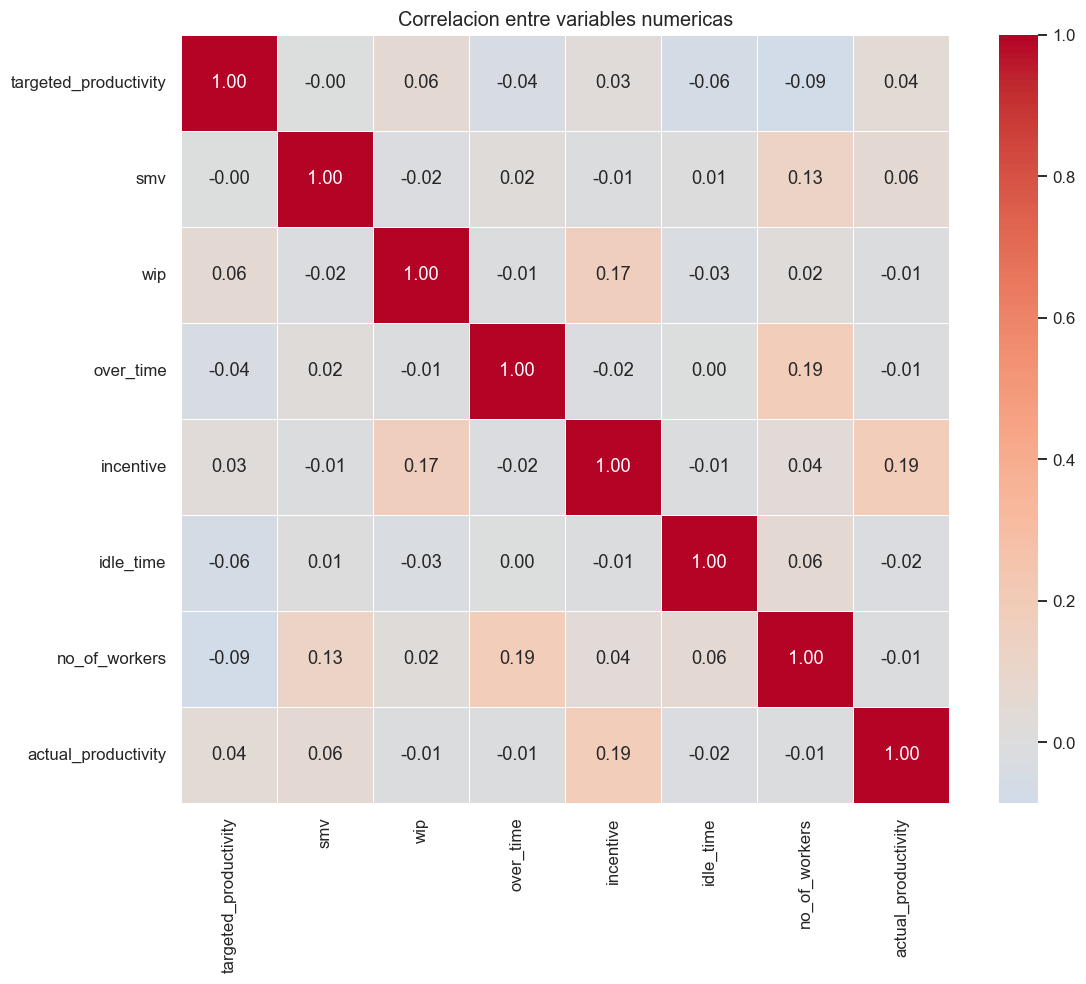

In [15]:
corr = df[vars_continuas].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4)
plt.title('Correlacion entre variables numericas', fontsize=13)
plt.tight_layout()
plt.show()

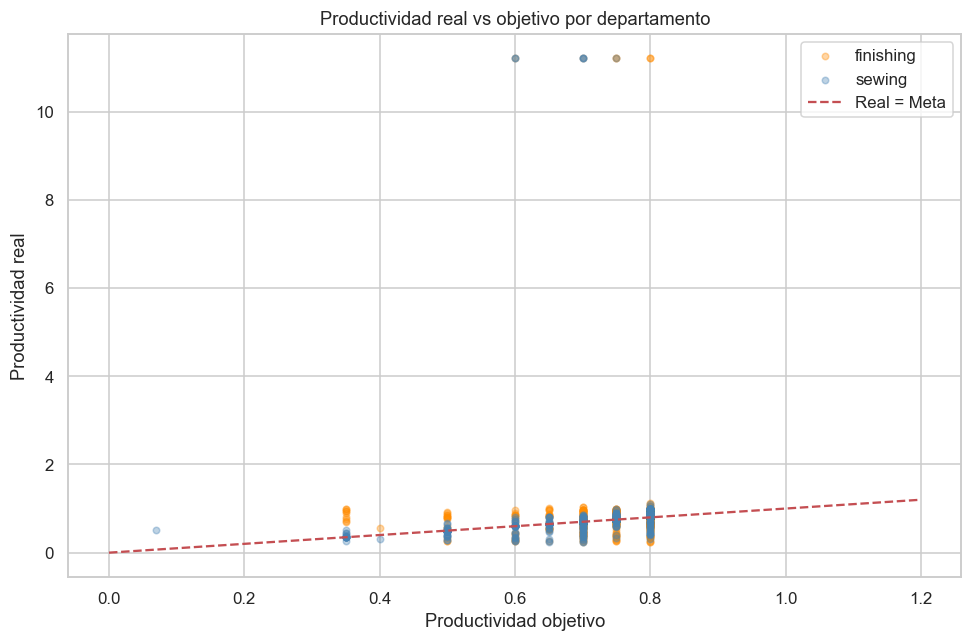

In [16]:
t = df.dropna(subset=['department','actual_productivity','targeted_productivity']).copy()
t['dept_clean'] = t['department'].str.strip().replace('sweing','sewing')
fig, ax = plt.subplots(figsize=(9, 6))
for dept, grp in t.groupby('dept_clean'):
    color = 'steelblue' if dept == 'sewing' else 'darkorange'
    ax.scatter(grp['targeted_productivity'], grp['actual_productivity'],
               label=dept, alpha=0.35, s=18, color=color)
ax.plot([0, 1.2], [0, 1.2], 'r--', lw=1.5, label='Real = Meta')
ax.set_xlabel('Productividad objetivo')
ax.set_ylabel('Productividad real')
ax.set_title('Productividad real vs objetivo por departamento')
ax.legend()
plt.tight_layout()
plt.show()

### 3g. Detección de datos inconsistentes

Valores que **existen** (no son nulos) pero son incorrectos: texto en campo numérico,
typos, valores fuera de rango u outliers físicamente imposibles.

In [17]:
# [1] Valor no numerico en 'team'
invalidos = df[pd.to_numeric(df['team'], errors='coerce').isnull() & df['team'].notna()]
print(f'[1] Valores no numericos en team: {len(invalidos)}')
print(invalidos[['date','department','day','team']])

# [2] Typos y espacios en 'department'
print('\n[2] Valores unicos en department (SIN limpiar):')
print(df['department'].value_counts())

# [3] actual_productivity fuera del rango [0, 1]
fuera = df[(df['actual_productivity'] < 0) | (df['actual_productivity'] > 1)]
print(f'\n[3] actual_productivity fuera de [0,1]: {len(fuera)} registros')

# [4] smv extremo
print('\n[4] smv > 100 minutos:')
print(df[df['smv'] > 100][['date','department','team','smv']])

# [5] over_time imposible
print('\n[5] over_time > 25000 minutos:')
print(df[df['over_time'] > 25000][['date','department','team','over_time']])

[1] Valores no numericos en team: 12
          date  department        day           team
34    1/3/2015      sweing   Saturday  invalid_value
104   1/7/2015  finishing   Wednesday  invalid_value
229  1/13/2015         NaN    Tuesday  invalid_value
372  1/22/2015  finishing    Thursday  invalid_value
378  1/22/2015      sweing   Thursday  invalid_value
384  1/22/2015  finishing    Thursday  invalid_value
438  1/26/2015  finishing      Monday  invalid_value
537  1/31/2015      sweing   Saturday  invalid_value
547   2/1/2015  finishing      Sunday  invalid_value
633   2/5/2015      sweing   Thursday  invalid_value
771  2/15/2015   finishing     Sunday  invalid_value
923  2/25/2015   finishing  Wednesday  invalid_value

[2] Valores unicos en department (SIN limpiar):
department
sweing        670
finishing     244
finishing     233
Name: count, dtype: int64

[3] actual_productivity fuera de [0,1]: 48 registros

[4] smv > 100 minutos:
           date  department           team    smv
25    

In [18]:
pd.DataFrame([
    ('team = invalid_value',        '1 fila',     'Texto en columna numerica'),
    ('department: espacio + typo',  'Todo el set','Trailing space y sweing vs sewing'),
    ('smv = 545.6',                 '1 fila',     'Outlier extremo (~28x la mediana)'),
    ('over_time = 129600 min',      '1 fila',     'Equivale a 90 dias laborales, imposible'),
    ('Valores negativos',           '0 filas',    'No detectados'),
], columns=['Inconsistencia','Alcance','Descripcion'])

,Inconsistencia,Alcance,Descripcion
0,team = invalid_value,1 fila,Texto en columna numerica
1,department: espacio + typo,Todo el set,Trailing space y sweing vs sewing
2,smv = 545.6,1 fila,Outlier extremo (~28x la mediana)
3,over_time = 129600 min,1 fila,"Equivale a 90 dias laborales, imposible"
4,Valores negativos,0 filas,No detectados


<a id="4"></a>
## 4. Pretratamiento de datos

A partir de los hallazgos del EDA aplicamos un plan de limpieza e imputación sobre una
**copia** del dataset original:

- **Corregir**: errores de formato y typos (`department`, `team`, `smv`, `over_time`).
- **Imputar con mediana del grupo**: `wip`, `no_of_workers`, `targeted_productivity`.
- **Imputar con 0**: `incentive`, `idle_time`, `idle_men`, `no_of_style_change` (faltante = ausencia del fenómeno).
- **Eliminar fila**: cuando el dato crítico no es recuperable (`team`, `department`, `actual_productivity` nulos).

In [19]:
df_clean = df.copy()
print(f'Filas antes de limpieza: {len(df_clean)}')

# 4.1 department: eliminar espacios y corregir typo
df_clean['department'] = df_clean['department'].str.strip().replace('sweing','sewing')

# 4.2 team: 'invalid_value' -> NaN via conversion numerica
df_clean['team'] = pd.to_numeric(df_clean['team'], errors='coerce')

# 4.3 date -> datetime; recuperar day donde sea posible
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%m/%d/%Y', errors='coerce')
dias = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',
        4:'Friday',5:'Saturday',6:'Sunday'}
mask = df_clean['day'].isnull() & df_clean['date'].notna()
df_clean.loc[mask,'day'] = df_clean.loc[mask,'date'].dt.dayofweek.map(dias)
print(f'Valores de day recuperados desde date: {mask.sum()}')

Filas antes de limpieza: 1207
Valores de day recuperados desde date: 59


In [20]:
# 4.4 Derivar quarter desde el dia del mes
def day_to_quarter(day):
    if day <= 7:  return 'Quarter1'
    if day <= 14: return 'Quarter2'
    if day <= 21: return 'Quarter3'
    return 'Quarter4'

mask_q = df_clean['quarter'].isnull() & df_clean['date'].notna()
df_clean.loc[mask_q, 'quarter'] = df_clean.loc[mask_q, 'date'].dt.day.apply(day_to_quarter)
print(f'Valores de quarter recuperados: {mask_q.sum()}')

Valores de quarter recuperados: 55


In [21]:
# 4.5 smv: corregir outlier (>100 -> mediana sewing) e imputar nulos por departamento
mediana_smv = df_clean[df_clean['department']=='sewing']['smv'].median()
n_fix = (df_clean['smv'] > 100).sum()
df_clean.loc[df_clean['smv'] > 100, 'smv'] = mediana_smv
df_clean['smv'] = df_clean.groupby('department')['smv'].transform(lambda x: x.fillna(x.median()))
df_clean['smv'] = df_clean['smv'].fillna(df_clean['smv'].median())
print(f'smv corregidos: {n_fix} outliers -> mediana sewing ({mediana_smv:.2f} min)')

# 4.6 over_time: corregir outlier (>25000 -> mediana finishing) e imputar nulos
mediana_ot = df_clean[df_clean['department']=='finishing']['over_time'].median()
n_fix = (df_clean['over_time'] > 25000).sum()
df_clean.loc[df_clean['over_time'] > 25000, 'over_time'] = mediana_ot
df_clean['over_time'] = df_clean.groupby('department')['over_time'].transform(lambda x: x.fillna(x.median()))
df_clean['over_time'] = df_clean['over_time'].fillna(df_clean['over_time'].median())
print(f'over_time corregidos: {n_fix} outliers -> mediana finishing ({mediana_ot:.0f} min)')

smv corregidos: 12 outliers -> mediana sewing (22.52 min)
over_time corregidos: 13 outliers -> mediana finishing (1440 min)


In [22]:
# 4.7 wip: finishing -> 0; sewing -> mediana del equipo
mask_fin = df_clean['department'] == 'finishing'
df_clean.loc[mask_fin, 'wip'] = df_clean.loc[mask_fin, 'wip'].fillna(0)
df_clean['wip'] = df_clean.groupby('team')['wip'].transform(lambda x: x.fillna(x.median()))
df_clean['wip'] = df_clean['wip'].fillna(df_clean.loc[~mask_fin, 'wip'].median())

# 4.8 targeted_productivity: mediana por departamento y dia
df_clean['targeted_productivity'] = (
    df_clean.groupby(['department', 'day'])['targeted_productivity']
    .transform(lambda x: x.fillna(x.median())))
df_clean['targeted_productivity'] = df_clean['targeted_productivity'].fillna(
    df_clean['targeted_productivity'].median())

# 4.9 no_of_workers: mediana del equipo
df_clean['no_of_workers'] = df_clean.groupby('team')['no_of_workers'].transform(lambda x: x.fillna(x.median()))
df_clean['no_of_workers'] = df_clean['no_of_workers'].fillna(df_clean['no_of_workers'].median())

# 4.10 Imputar con 0 (faltante = ausencia del fenomeno)
for col in ['incentive', 'idle_time', 'idle_men', 'no_of_style_change']:
    df_clean[col] = df_clean[col].fillna(0)
print('Imputaciones de wip, targeted_productivity, no_of_workers y columnas-cero aplicadas.')

Imputaciones de wip, targeted_productivity, no_of_workers y columnas-cero aplicadas.


In [23]:
# 4.11 Eliminar filas sin team o sin actual_productivity (objetivo)
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['team'])
df_clean = df_clean.dropna(subset=['actual_productivity'])

# 4.11b actual_productivity fuera de [0,1]: >1.2 se elimina; (1,1.2] se recorta a 1.0
df_clean = df_clean[df_clean['actual_productivity'] <= 1.2]
recortados = (df_clean['actual_productivity'] > 1).sum()
df_clean['actual_productivity'] = df_clean['actual_productivity'].clip(upper=1.0)

# 4.12-4.14 department nulo, duplicados y team a entero
df_clean = df_clean.dropna(subset=['department'])
df_clean = df_clean.drop_duplicates()
df_clean['team'] = df_clean['team'].astype(int)
print(f'Filas eliminadas en total: {antes - len(df_clean)} (recortados a 1.0: {recortados})')

Filas eliminadas en total: 194 (recortados a 1.0: 33)


In [24]:
print('============================================')
print('      ESTADO FINAL DEL DATASET LIMPIO')
print('============================================')
print(f'Filas originales: {len(df)}')
print(f'Filas finales:    {len(df_clean)}')
print(f'Filas perdidas:   {len(df)-len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')
nulos_final = df_clean.isnull().sum()
nulos_final = nulos_final[nulos_final > 0]
print('Nulos restantes:', 'NINGUNO' if len(nulos_final)==0 else f'\n{nulos_final}')
print('Departamentos:', df_clean['department'].unique())

# Guardar dataset limpio para las etapas siguientes
df_clean.to_csv('Tema_11_clean.csv', index=False)
print('\nGuardado: Tema_11_clean.csv')

      ESTADO FINAL DEL DATASET LIMPIO
Filas originales: 1207
Filas finales:    1013
Filas perdidas:   194 (16.1%)
Nulos restantes: 
date       47
quarter     5
day         2
dtype: int64
Departamentos: ['sewing' 'finishing']

Guardado: Tema_11_clean.csv


### 4b. Normalización de variables continuas

Variables con rangos muy distintos (ej. `over_time` en miles vs `idle_men` en decenas)
distorsionan algoritmos basados en distancias o gradientes. Comparamos dos esquemas:
**Min-Max** ([0,1]) y **Z-score** (media 0, desvío 1). La estandarización (Z-score) es la
que usaremos luego para PCA y los modelos.

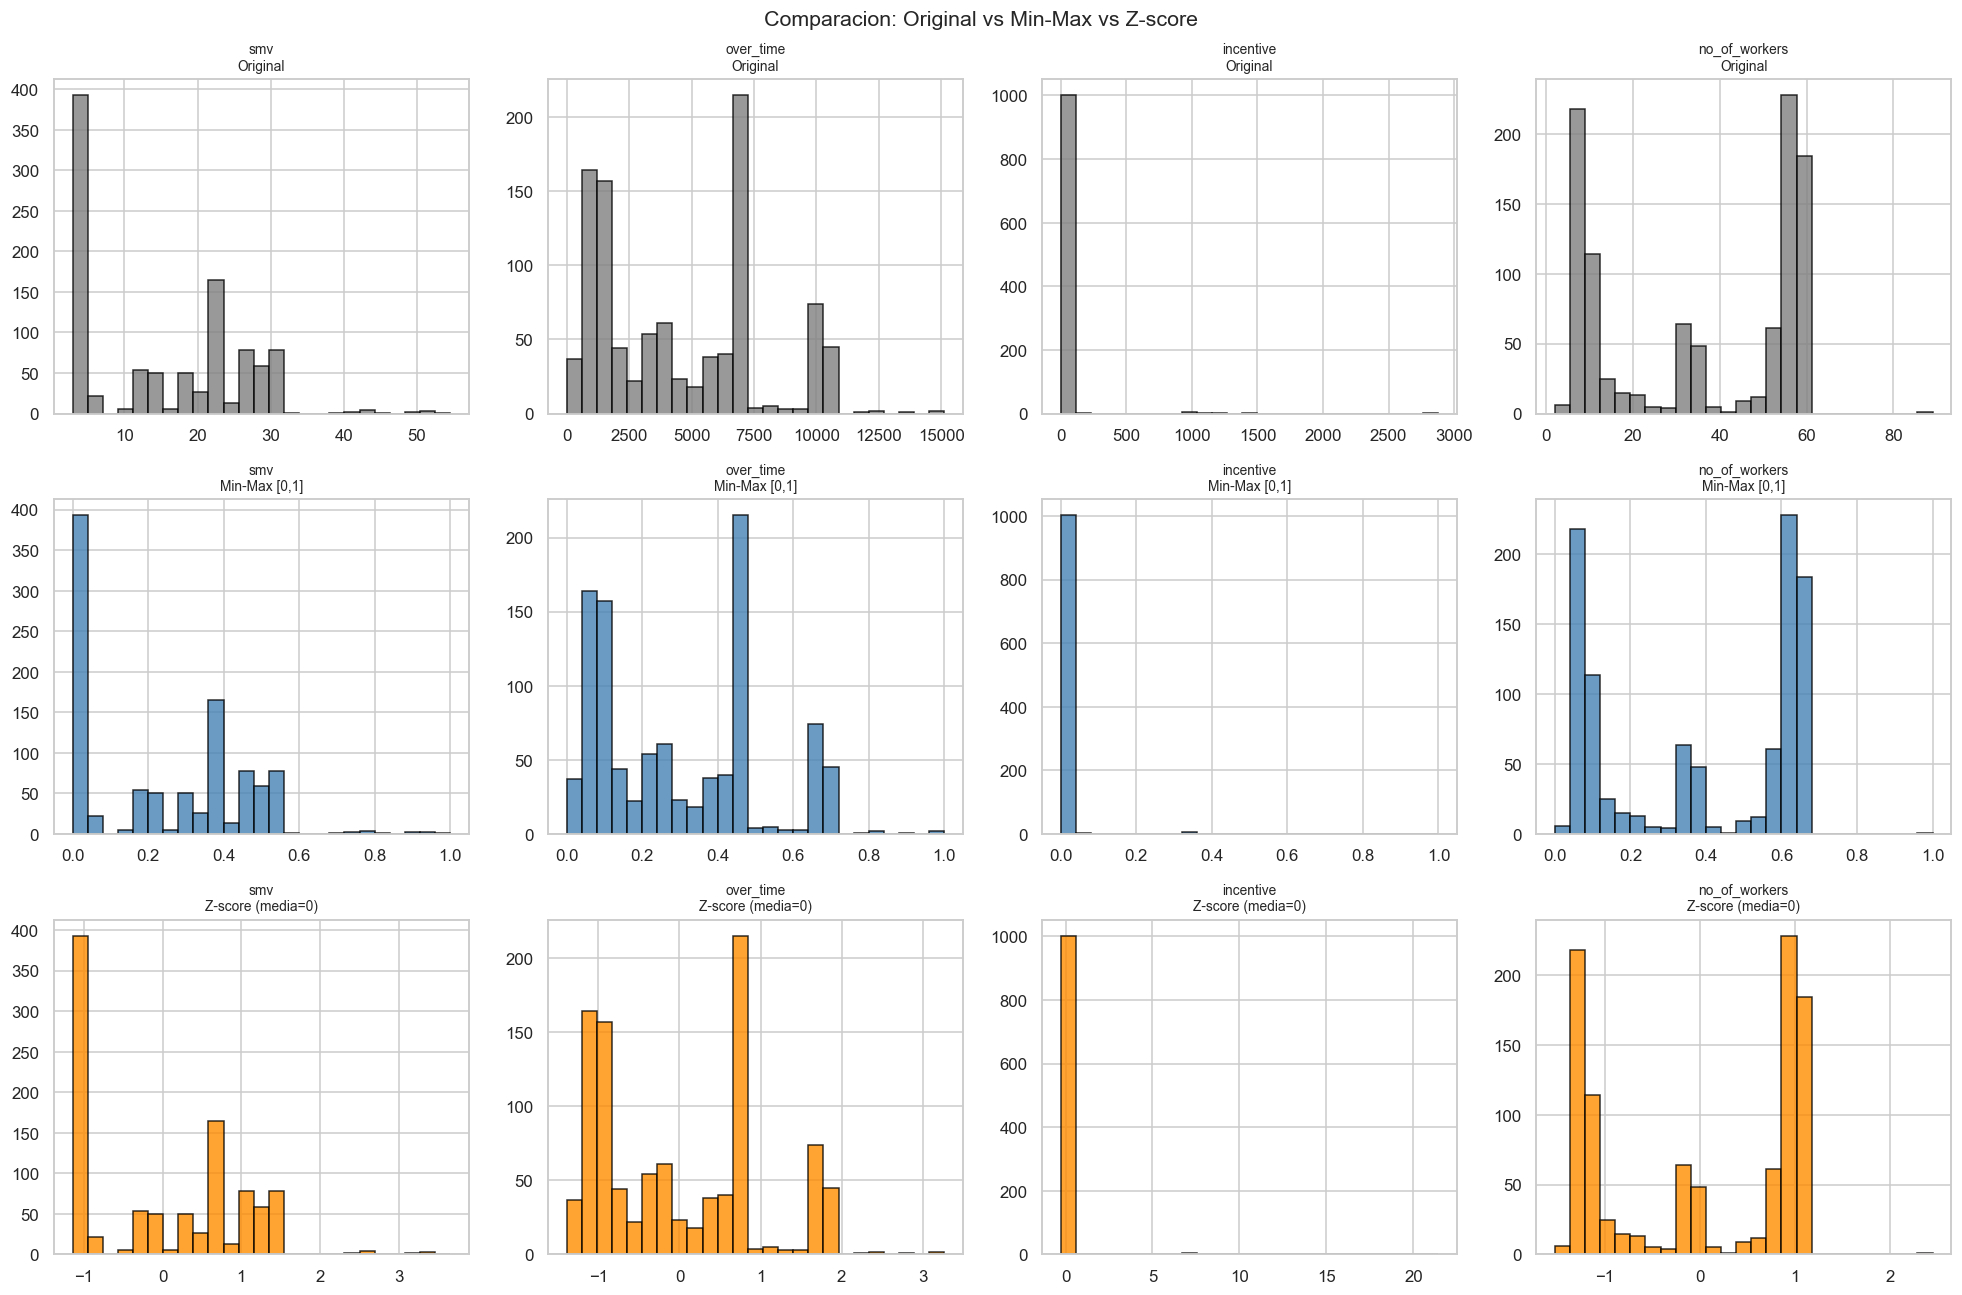

In [25]:
vars_normalizar = ['smv','wip','over_time','incentive',
                   'idle_time','idle_men','no_of_workers','no_of_style_change']

df_minmax = df_clean.copy()
df_minmax[vars_normalizar] = MinMaxScaler().fit_transform(df_clean[vars_normalizar])

df_standard = df_clean.copy()
df_standard[vars_normalizar] = StandardScaler().fit_transform(df_clean[vars_normalizar])

vars_mostrar = ['smv','over_time','incentive','no_of_workers']
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
cfg = [('Original', df_clean, 'gray'),
       ('Min-Max [0,1]', df_minmax, 'steelblue'),
       ('Z-score (media=0)', df_standard, 'darkorange')]
for fila, (titulo, ds, color) in enumerate(cfg):
    for j, col in enumerate(vars_mostrar):
        axes[fila,j].hist(ds[col].dropna(), bins=25, color=color, edgecolor='black', alpha=0.8)
        axes[fila,j].set_title(f'{col}\n{titulo}', fontsize=9)
plt.suptitle('Comparacion: Original vs Min-Max vs Z-score', fontsize=14)
plt.tight_layout()
plt.show()

<a id="5"></a>
## 5. Análisis de datos mediante visualizaciones (PCA)

Aplicamos **Análisis de Componentes Principales (PCA)** sobre el dataset limpio para
visualizar la estructura de los datos en pocas dimensiones, identificar relaciones entre
variables y ver qué características distinguen a los equipos que **cumplen** su objetivo
de productividad de los que **no**.

### 5.1 Preprocesamiento para PCA — codificación de variables categóricas

| Variable | Tipo | Estrategia |
|---|---|---|
| `department` | Nominal binaria | sewing=1, finishing=0 |
| `quarter` | Ordinal | Q1=1 … Q5=5 |
| `day` | Cíclica | codificación sin/cos (preserva periodicidad semanal) |
| `date` | Redundante | eliminada |

In [26]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Partimos del dataset limpio guardado
df_pca = pd.read_csv('Tema_11_clean.csv').drop(columns=['date']).dropna().reset_index(drop=True)

df_pca['department_enc'] = (df_pca['department'] == 'sewing').astype(int)
quarter_map = {'Quarter1':1,'Quarter2':2,'Quarter3':3,'Quarter4':4,'Quarter5':5}
df_pca['quarter_enc'] = df_pca['quarter'].map(quarter_map)
day_order = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
df_pca['day_num'] = df_pca['day'].map(day_order)
df_pca['day_sin'] = np.sin(2*np.pi*df_pca['day_num']/7)
df_pca['day_cos'] = np.cos(2*np.pi*df_pca['day_num']/7)

# Variable de color: cumplio o no su objetivo de productividad
df_pca['met_target'] = (df_pca['actual_productivity'] >= df_pca['targeted_productivity']).astype(int)
print(f"Cumplieron objetivo: {df_pca['met_target'].sum()} ({df_pca['met_target'].mean()*100:.1f}%)")
print(f"No cumplieron:       {(df_pca['met_target']==0).sum()} ({(1-df_pca['met_target'].mean())*100:.1f}%)")

Cumplieron objetivo: 726 (72.2%)
No cumplieron:       280 (27.8%)


In [27]:
feature_cols = ['targeted_productivity','smv','wip','over_time','incentive',
    'idle_time','idle_men','no_of_style_change','no_of_workers',
    'actual_productivity','department_enc','quarter_enc','day_sin','day_cos','team']
feature_labels = ['Prod. Obj.','SMV','WIP','Horas Extra','Incentivo',
    'T. Inactivo','Op. Inactivos','Cambios Estilo','N° Operarios',
    'Prod. Real','Depart.','Trimestre','Día (sen)','Día (cos)','Equipo']

X = df_pca[feature_cols].values
y = df_pca['met_target'].values

X_scaled = StandardScaler().fit_transform(X)
pca = PCA().fit(X_scaled)
X_pca = pca.transform(X_scaled)
var_exp = pca.explained_variance_ratio_
cum_var = np.cumsum(var_exp)
loadings = pca.components_.T

print('Varianza explicada por componente:')
for i,(v,cv) in enumerate(zip(var_exp[:8], cum_var[:8])):
    print(f'  PC{i+1}: {v*100:5.2f}%   Acumulada: {cv*100:6.2f}%')

Varianza explicada por componente:
  PC1: 24.41%   Acumulada:  24.41%
  PC2: 11.75%   Acumulada:  36.17%
  PC3:  9.10%   Acumulada:  45.26%
  PC4:  8.04%   Acumulada:  53.30%
  PC5:  6.92%   Acumulada:  60.22%
  PC6:  6.72%   Acumulada:  66.94%
  PC7:  6.60%   Acumulada:  73.55%
  PC8:  5.80%   Acumulada:  79.35%


### 5.2 Scree plot y varianza acumulada

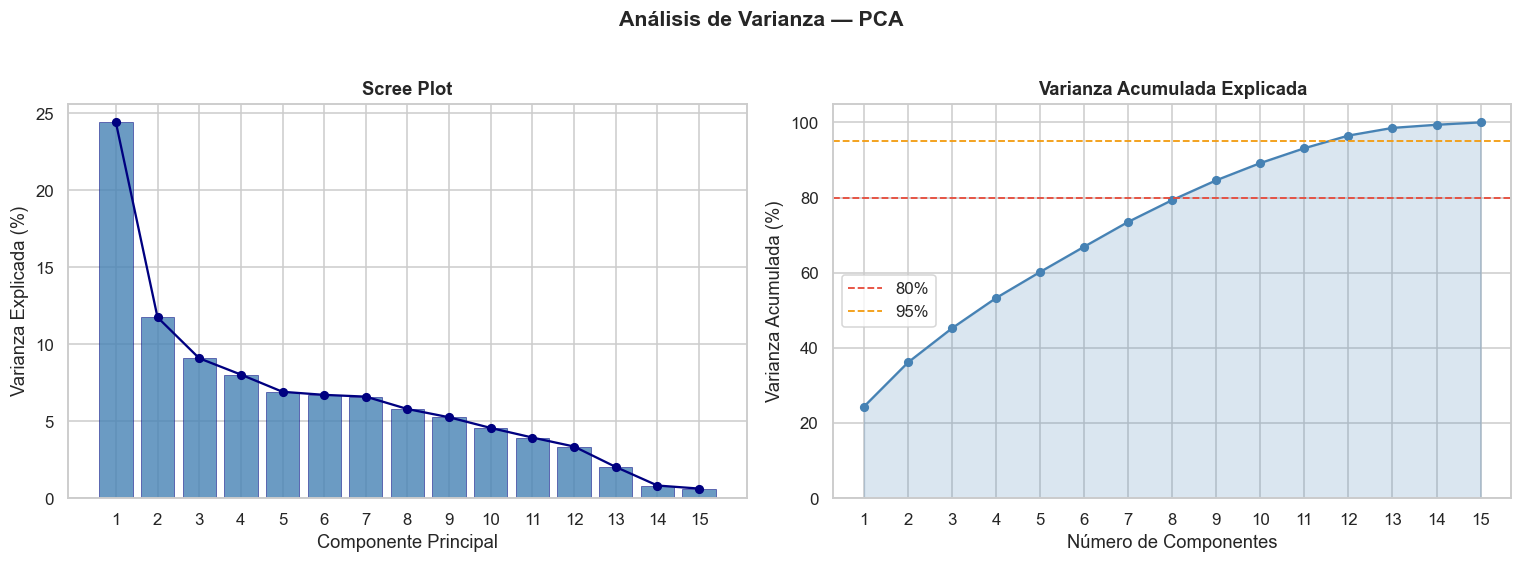

PC1+PC2 explican el 36.17% de la varianza total.
PC1+PC2+PC3 explican el 45.26% de la varianza total.


In [28]:
n_comp = len(var_exp)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax1.bar(range(1,n_comp+1), var_exp*100, color='steelblue', alpha=0.8, edgecolor='navy', linewidth=0.4)
ax1.plot(range(1,n_comp+1), var_exp*100, 'o-', color='navy', markersize=5)
ax1.set_xlabel('Componente Principal'); ax1.set_ylabel('Varianza Explicada (%)')
ax1.set_title('Scree Plot', fontweight='bold'); ax1.set_xticks(range(1,n_comp+1))
ax2 = axes[1]
ax2.fill_between(range(1,n_comp+1), cum_var*100, alpha=0.2, color='steelblue')
ax2.plot(range(1,n_comp+1), cum_var*100, 'o-', color='steelblue', markersize=5)
ax2.axhline(80, color='#e74c3c', linestyle='--', label='80%', linewidth=1.2)
ax2.axhline(95, color='#f39c12', linestyle='--', label='95%', linewidth=1.2)
ax2.set_xlabel('Número de Componentes'); ax2.set_ylabel('Varianza Acumulada (%)')
ax2.set_title('Varianza Acumulada Explicada', fontweight='bold')
ax2.set_xticks(range(1,n_comp+1)); ax2.set_ylim(0,105); ax2.legend()
plt.suptitle('Análisis de Varianza — PCA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('scree_plot.png', bbox_inches='tight'); plt.show()
print(f'PC1+PC2 explican el {cum_var[1]*100:.2f}% de la varianza total.')
print(f'PC1+PC2+PC3 explican el {cum_var[2]*100:.2f}% de la varianza total.')

### 5.3 Biplots

Cada punto es un registro (equipo/turno). Los **vectores** indican cómo contribuye cada
variable original a los componentes. El color indica si el equipo **cumplió** (verde) o
**no** (rojo) su objetivo de productividad.

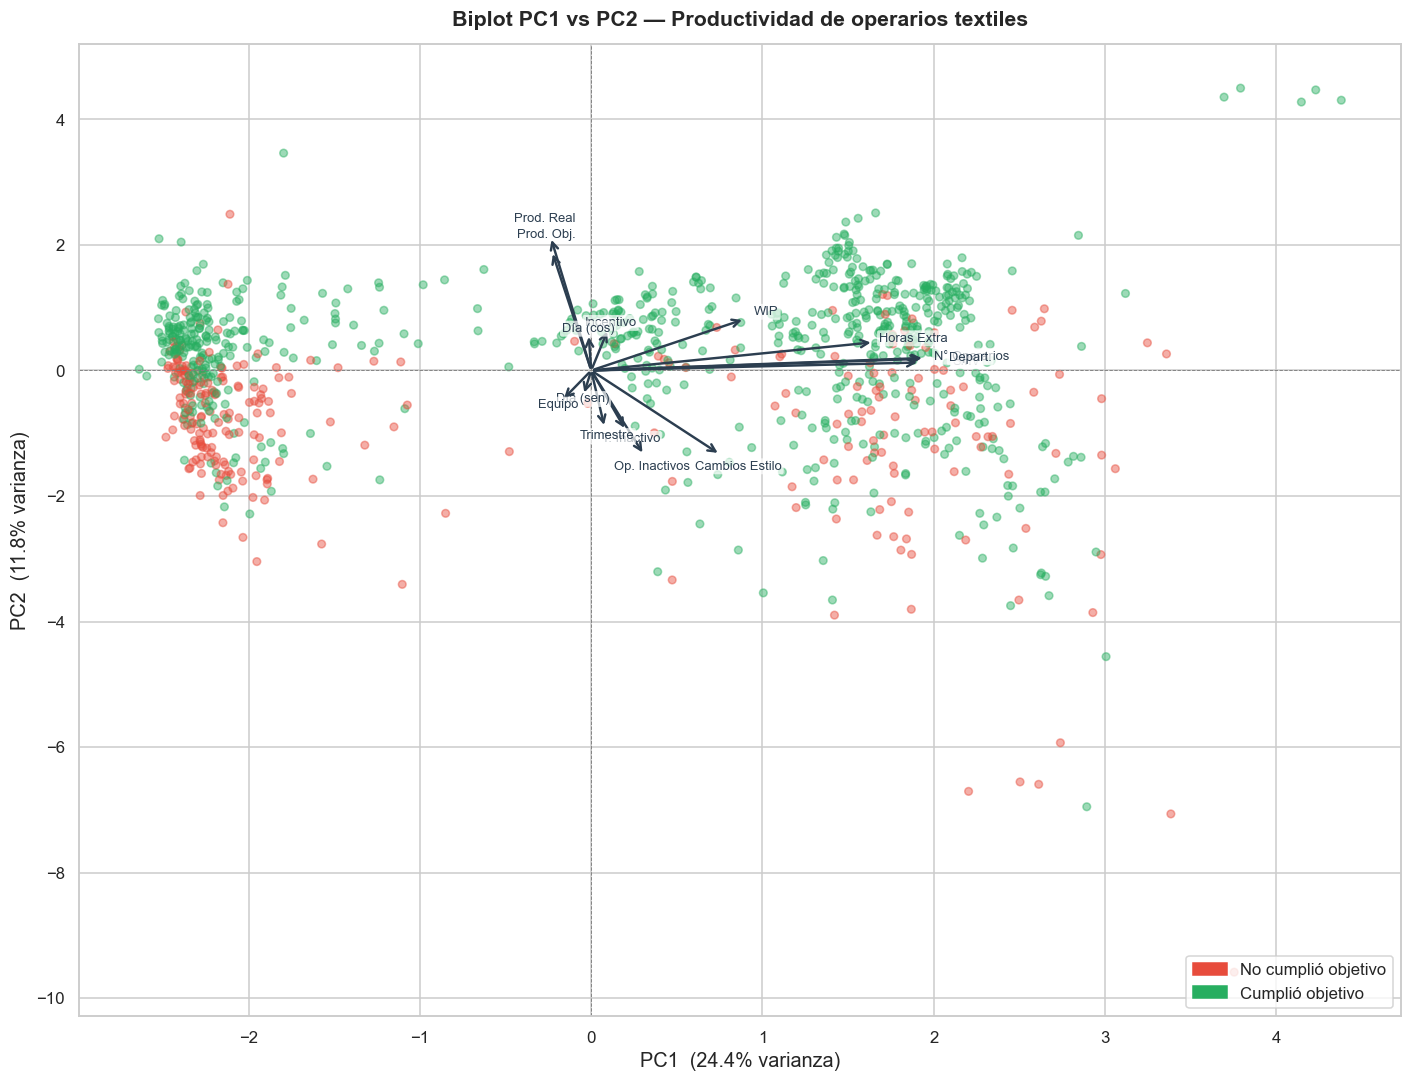

In [29]:
def biplot(X_pca, loadings, labels_feat, labels_obs, var_exp, pc_x=0, pc_y=1, title='Biplot'):
    fig, ax = plt.subplots(figsize=(13, 10))
    color_map = {0:'#e74c3c', 1:'#27ae60'}
    colors = [color_map[l] for l in labels_obs]
    ax.scatter(X_pca[:,pc_x], X_pca[:,pc_y], c=colors, alpha=0.45, s=25, zorder=2)
    score_range = max(np.percentile(np.abs(X_pca[:,pc_x]),95), np.percentile(np.abs(X_pca[:,pc_y]),95))
    load_range = max(np.abs(loadings[:,pc_x]).max(), np.abs(loadings[:,pc_y]).max())
    scale = score_range/load_range*0.85
    for i, name in enumerate(labels_feat):
        lx, ly = loadings[i,pc_x]*scale, loadings[i,pc_y]*scale
        ax.annotate('', xy=(lx,ly), xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.6))
        ax.text(lx*1.14, ly*1.14, name, fontsize=8.5, color='#2c3e50', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))
    ax.axhline(0, color='gray', lw=0.6, ls='--'); ax.axvline(0, color='gray', lw=0.6, ls='--')
    ax.set_xlabel(f'PC{pc_x+1}  ({var_exp[pc_x]*100:.1f}% varianza)', fontsize=13)
    ax.set_ylabel(f'PC{pc_y+1}  ({var_exp[pc_y]*100:.1f}% varianza)', fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.legend(handles=[mpatches.Patch(color='#e74c3c', label='No cumplió objetivo'),
                       mpatches.Patch(color='#27ae60', label='Cumplió objetivo')],
              loc='lower right', fontsize=11)
    plt.tight_layout(); return fig, ax

biplot(X_pca, loadings, feature_labels, y, var_exp, 0, 1,
       'Biplot PC1 vs PC2 — Productividad de operarios textiles')
plt.savefig('biplot_pc1_pc2.png', bbox_inches='tight'); plt.show()

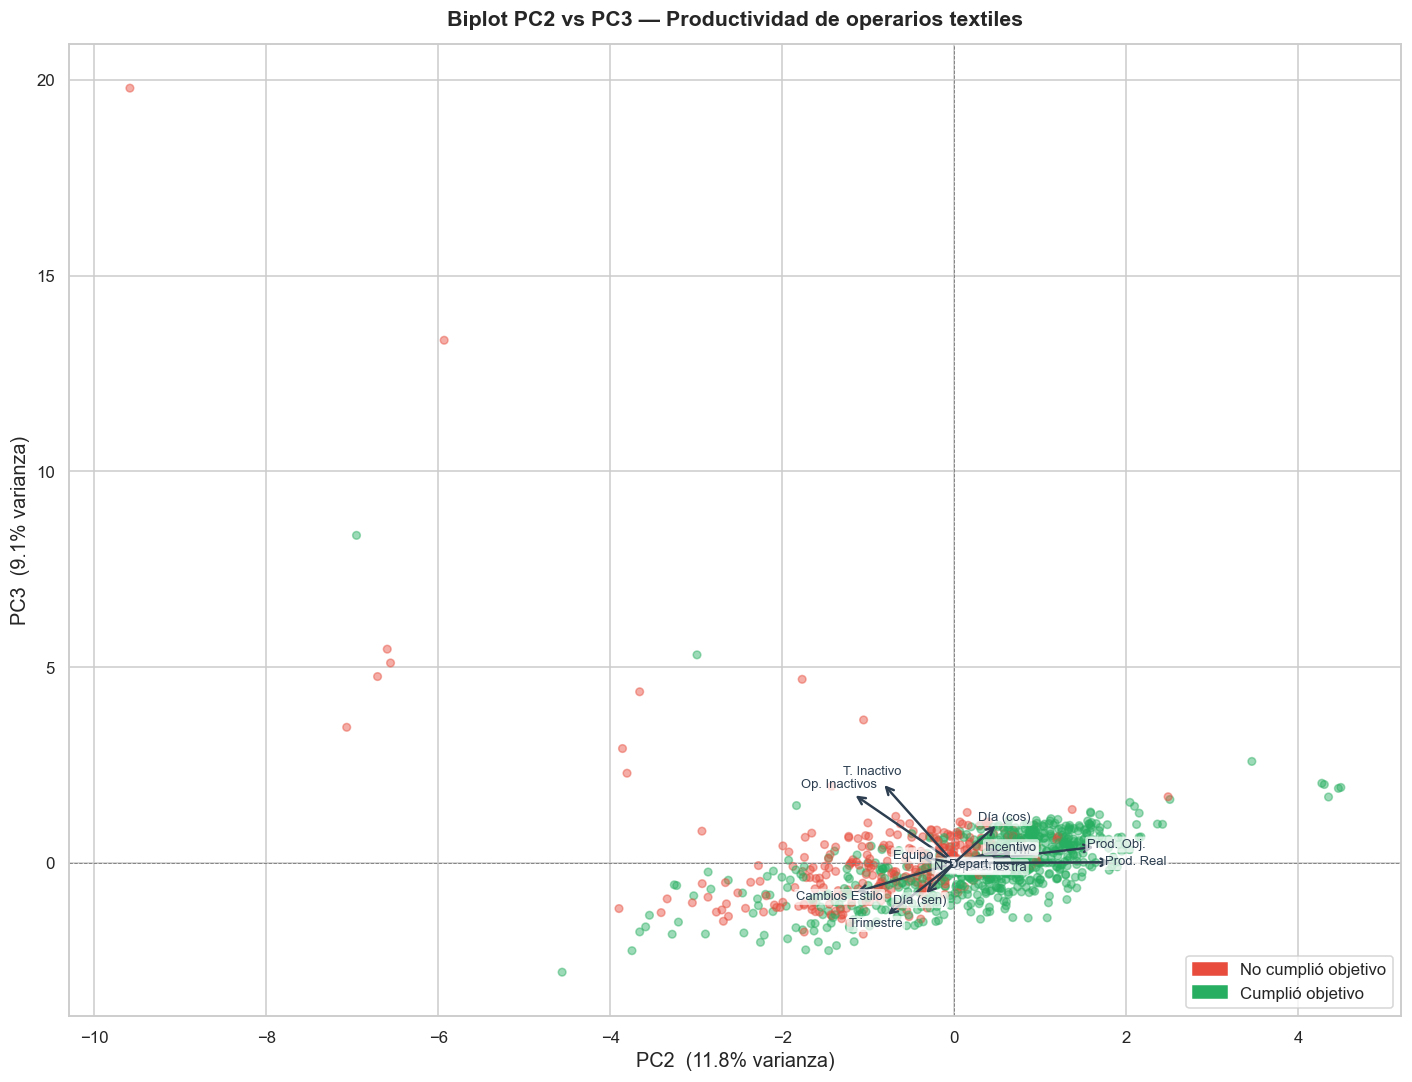

In [30]:
biplot(X_pca, loadings, feature_labels, y, var_exp, 1, 2,
       'Biplot PC2 vs PC3 — Productividad de operarios textiles')
plt.savefig('biplot_pc2_pc3.png', bbox_inches='tight'); plt.show()

### 5.4 Importancia de variables (loadings)

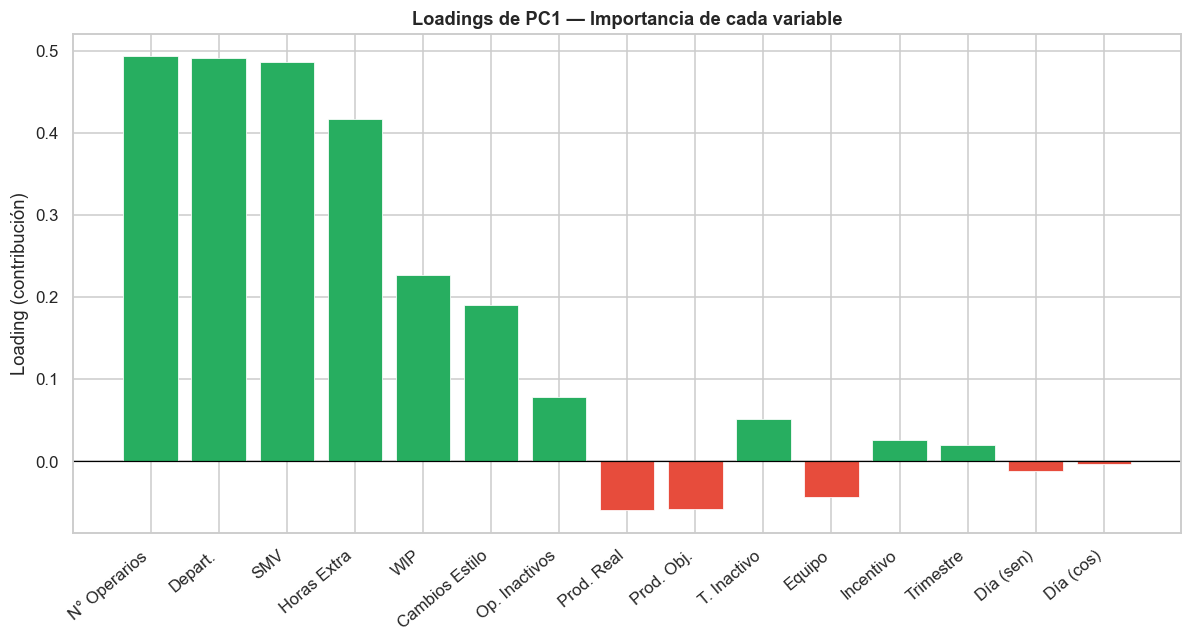

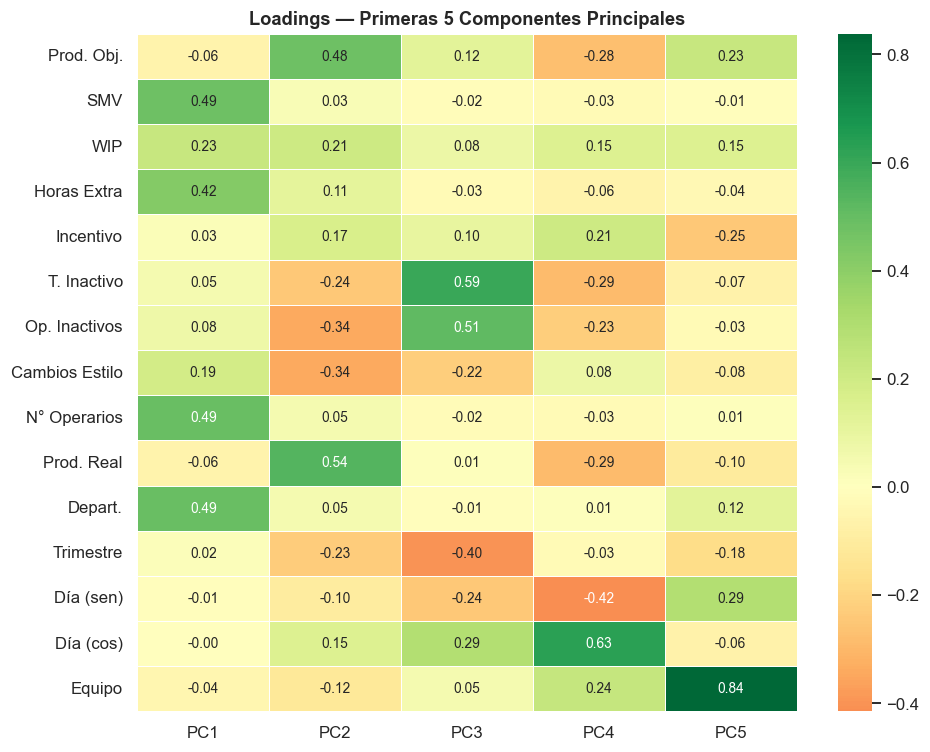

In [31]:
pc1_series = pd.Series(loadings[:,0], index=feature_labels)
pc1_sorted = pc1_series.reindex(pc1_series.abs().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in pc1_sorted]
bars = ax.bar(range(len(pc1_sorted)), pc1_sorted.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(pc1_sorted))); ax.set_xticklabels(pc1_sorted.index, rotation=40, ha='right')
ax.axhline(0, color='black', lw=0.8); ax.set_ylabel('Loading (contribución)')
ax.set_title('Loadings de PC1 — Importancia de cada variable', fontweight='bold')
plt.tight_layout(); plt.savefig('pc1_loadings.png', bbox_inches='tight'); plt.show()

loadings_df = pd.DataFrame(loadings[:,:5], index=feature_labels, columns=[f'PC{i+1}' for i in range(5)])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax, annot_kws={'size':9})
ax.set_title('Loadings — Primeras 5 Componentes Principales', fontweight='bold')
plt.tight_layout(); plt.savefig('loadings_heatmap.png', bbox_inches='tight'); plt.show()

### 5.5 Lectura de los resultados de PCA

- **PC1 + PC2** explican en conjunto alrededor de un tercio de la varianza total. Para
  superar el 80 % se necesitan 7–8 componentes: la estructura de los datos es **compleja
  y multidimensional**, lo que adelanta que un modelo lineal simple no bastará.
- En el **biplot PC1 vs PC2**, los equipos que cumplen su objetivo (verde) tienden a la
  región positiva de PC1 y los que no cumplen (rojo) a la negativa, aunque con fuerte
  superposición: PC1 captura una dimensión de *escala/rendimiento operativo*.
- **WIP, Horas Extra y N° de Operarios** apuntan en direcciones similares (correlación
  positiva: equipos grandes hacen más horas extra y acumulan más trabajo en proceso).
  **Prod. Real** y **Prod. Objetivo** están alineadas. **T. Inactivo** y **Op. Inactivos**
  se oponen a esa dirección.
- En **PC2 vs PC3** la separación cumplió/no cumplió se diluye y ganan peso las variables
  **temporales** (Trimestre, Día sin/cos): PC3 recoge variación estacional.

Estas relaciones guían la selección de variables del modelo predictivo de la sección 6.

<a id="6"></a>
## 6. Construcción del modelo predictivo

Predecimos `actual_productivity` (continua) con modelos supervisados de regresión.
Recorremos: (i) dos modelos con variables elegidas manualmente, (ii) iteración ampliando
variables y probando ensembles, (iii) validación cruzada y optimización automática de
hiperparámetros, y (iv) comparación final.

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Mismo preprocesamiento que en PCA, ahora con target continuo
dfm = pd.read_csv('Tema_11_clean.csv').drop(columns=['date']).dropna().reset_index(drop=True)
dfm['department_enc'] = (dfm['department'] == 'sewing').astype(int)
dfm['quarter_enc'] = dfm['quarter'].map(quarter_map)
dfm['day_num'] = dfm['day'].map(day_order)
dfm['day_sin'] = np.sin(2*np.pi*dfm['day_num']/7)
dfm['day_cos'] = np.cos(2*np.pi*dfm['day_num']/7)

ALL_FEATURES = ['targeted_productivity','smv','wip','over_time','incentive',
    'idle_time','idle_men','no_of_style_change','no_of_workers',
    'department_enc','quarter_enc','day_sin','day_cos','team']
TARGET = 'actual_productivity'
X_all = dfm[ALL_FEATURES].values
yv = dfm[TARGET].values
print(f'Features disponibles: {len(ALL_FEATURES)}   Muestras: {len(yv)}')
print(f'Target — media: {yv.mean():.3f}  std: {yv.std():.3f}  rango: [{yv.min():.3f}, {yv.max():.3f}]')

Features disponibles: 14   Muestras: 1006
Target — media: 0.732  std: 0.175  rango: [0.234, 1.000]


### 6.1 División train/test y estandarización

División **80 % entrenamiento / 20 % prueba** con semilla fija. El escalado se ajusta
**solo con el train** y se aplica al test (evita fuga de información).

In [33]:
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, yv, test_size=0.2, random_state=42)
scaler_m = StandardScaler()
X_train_sc_all = scaler_m.fit_transform(X_train_all)
X_test_sc_all = scaler_m.transform(X_test_all)
print(f'Entrenamiento: {len(y_train)} muestras   Prueba: {len(y_test)} muestras')

def metricas(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<40} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return {'Modelo': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}
resultados = []

Entrenamiento: 804 muestras   Prueba: 202 muestras


### 6.2 Dos modelos con variables seleccionadas manualmente (Intento 1)

Elegimos 6 variables con relación intuitiva con la productividad: meta, horas extra,
incentivo, tiempos muertos y departamento.

In [34]:
FEATS_1 = ['targeted_productivity','over_time','incentive','idle_time','idle_men','department_enc']
idx_1 = [ALL_FEATURES.index(f) for f in FEATS_1]
X_tr1, X_te1 = X_train_sc_all[:,idx_1], X_test_sc_all[:,idx_1]

lr1 = LinearRegression().fit(X_tr1, y_train)
resultados.append(metricas('Regresión Lineal — Intento 1', y_test, lr1.predict(X_te1)))

dt1 = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42).fit(X_tr1, y_train)
resultados.append(metricas('Árbol de Decisión — Intento 1', y_test, dt1.predict(X_te1)))

  Regresión Lineal — Intento 1             RMSE=0.1498  MAE=0.1059  R²=0.2189
  Árbol de Decisión — Intento 1            RMSE=0.1464  MAE=0.0964  R²=0.2543


### 6.3 Iteración: ampliar variables y probar ensembles

**Intento 2** suma las variables que el PCA destacó en PC1 (SMV, WIP, N° operarios,
cambios de estilo). **Intento 3** usa las 14 features. **Intento 4** prueba ensembles
(Bagging y Random Forest).

In [35]:
# Intento 2 (10 features)
FEATS_2 = ['targeted_productivity','smv','wip','over_time','incentive',
           'idle_time','idle_men','no_of_style_change','no_of_workers','department_enc']
idx_2 = [ALL_FEATURES.index(f) for f in FEATS_2]
X_tr2, X_te2 = X_train_sc_all[:,idx_2], X_test_sc_all[:,idx_2]
resultados.append(metricas('Regresión Lineal — Intento 2', y_test, LinearRegression().fit(X_tr2,y_train).predict(X_te2)))
resultados.append(metricas('Árbol de Decisión — Intento 2', y_test, DecisionTreeRegressor(max_depth=6,min_samples_leaf=8,random_state=42).fit(X_tr2,y_train).predict(X_te2)))
resultados.append(metricas('KNN (k=7)     — Intento 2', y_test, KNeighborsRegressor(n_neighbors=7).fit(X_tr2,y_train).predict(X_te2)))

# Intento 3 (14 features)
X_tr3, X_te3 = X_train_sc_all, X_test_sc_all
resultados.append(metricas('Regresión Lineal — Intento 3', y_test, LinearRegression().fit(X_tr3,y_train).predict(X_te3)))
resultados.append(metricas('Árbol de Decisión — Intento 3', y_test, DecisionTreeRegressor(max_depth=7,min_samples_leaf=5,random_state=42).fit(X_tr3,y_train).predict(X_te3)))
resultados.append(metricas('KNN (k=5)     — Intento 3', y_test, KNeighborsRegressor(n_neighbors=5).fit(X_tr3,y_train).predict(X_te3)))

# Intento 4 (ensembles)
resultados.append(metricas('Bagging       — Intento 4', y_test, BaggingRegressor(n_estimators=100,random_state=42).fit(X_tr3,y_train).predict(X_te3)))
rf4 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_tr3, y_train)
y_pred_rf4 = rf4.predict(X_te3)
resultados.append(metricas('Random Forest — Intento 4', y_test, y_pred_rf4))

  Regresión Lineal — Intento 2             RMSE=0.1459  MAE=0.1048  R²=0.2597
  Árbol de Decisión — Intento 2            RMSE=0.1465  MAE=0.0890  R²=0.2532
  KNN (k=7)     — Intento 2                RMSE=0.1444  MAE=0.0950  R²=0.2742
  Regresión Lineal — Intento 3             RMSE=0.1448  MAE=0.1037  R²=0.2708
  Árbol de Decisión — Intento 3            RMSE=0.1480  MAE=0.0905  R²=0.2376
  KNN (k=5)     — Intento 3                RMSE=0.1483  MAE=0.1015  R²=0.2350


  Bagging       — Intento 4                RMSE=0.1295  MAE=0.0805  R²=0.4166
  Random Forest — Intento 4                RMSE=0.1303  MAE=0.0810  R²=0.4096


In [36]:
df_res = pd.DataFrame(resultados).sort_values('RMSE').reset_index(drop=True)
print('=== Todos los intentos manuales (ordenados por RMSE) ===')
print(df_res.round(4).to_string(index=False))
best_manual = df_res.iloc[0]
print(f'\n>>> MEJOR MODELO MANUAL: {best_manual["Modelo"]}  RMSE={best_manual["RMSE"]:.4f}  R²={best_manual["R²"]:.4f}')

=== Todos los intentos manuales (ordenados por RMSE) ===
                       Modelo   RMSE    MAE     R²
    Bagging       — Intento 4 0.1295 0.0805 0.4166
    Random Forest — Intento 4 0.1303 0.0810 0.4096
    KNN (k=7)     — Intento 2 0.1444 0.0950 0.2742
 Regresión Lineal — Intento 3 0.1448 0.1037 0.2708
 Regresión Lineal — Intento 2 0.1459 0.1048 0.2597
Árbol de Decisión — Intento 1 0.1464 0.0964 0.2543
Árbol de Decisión — Intento 2 0.1465 0.0890 0.2532
Árbol de Decisión — Intento 3 0.1480 0.0905 0.2376
    KNN (k=5)     — Intento 3 0.1483 0.1015 0.2350
 Regresión Lineal — Intento 1 0.1498 0.1059 0.2189

>>> MEJOR MODELO MANUAL: Bagging       — Intento 4  RMSE=0.1295  R²=0.4166


### 6.4 Validación cruzada (5-fold) y optimización automática (GridSearchCV)

In [37]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
modelos_cv = {
    'Regresión Lineal': LinearRegression(),
    'Árbol de Decisión': DecisionTreeRegressor(max_depth=7, min_samples_leaf=5, random_state=42),
    'Bagging': BaggingRegressor(n_estimators=100, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
}
cv_resultados = []
print('Validación cruzada 5-fold (todas las features):\n')
for nombre, modelo in modelos_cv.items():
    rmse_cv = -cross_val_score(modelo, X_train_sc_all, y_train, cv=kfold,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
    print(f'  {nombre:<22} CV-RMSE = {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}')
    cv_resultados.append({'Modelo':nombre,'CV-RMSE media':rmse_cv.mean(),'CV-RMSE std':rmse_cv.std()})
df_cv = pd.DataFrame(cv_resultados).sort_values('CV-RMSE media')
print(f'\nMejor modelo en CV: {df_cv.iloc[0]["Modelo"]}')

Validación cruzada 5-fold (todas las features):



  Regresión Lineal       CV-RMSE = 0.1540 ± 0.0109


  Árbol de Decisión      CV-RMSE = 0.1410 ± 0.0122


  Bagging                CV-RMSE = 0.1305 ± 0.0083


  Random Forest          CV-RMSE = 0.1302 ± 0.0082
  KNN                    CV-RMSE = 0.1503 ± 0.0141

Mejor modelo en CV: Random Forest


In [38]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
    cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
print('Ejecutando GridSearchCV sobre Random Forest (54 combinaciones x 5 folds)...')
grid_search.fit(X_train_sc_all, y_train)
print('\nMejores hiperparámetros:')
for k,v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'CV-RMSE del mejor modelo: {-grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_
y_pred_best_auto = best_rf.predict(X_test_sc_all)

Ejecutando GridSearchCV sobre Random Forest (54 combinaciones x 5 folds)...



Mejores hiperparámetros:
  max_depth: 10
  max_features: sqrt
  min_samples_split: 5
  n_estimators: 300
CV-RMSE del mejor modelo: 0.1277


<a id="7"></a>
## 7. Resultados obtenidos

Comparamos el **mejor modelo manual** (Random Forest con parámetros por defecto,
Intento 4) con el **mejor modelo automatizado** (Random Forest optimizado por
GridSearchCV), evaluados sobre la base de prueba.

In [39]:
rmse_man = np.sqrt(mean_squared_error(y_test, y_pred_rf4))
mae_man  = mean_absolute_error(y_test, y_pred_rf4)
r2_man   = r2_score(y_test, y_pred_rf4)
rmse_auto = np.sqrt(mean_squared_error(y_test, y_pred_best_auto))
mae_auto  = mean_absolute_error(y_test, y_pred_best_auto)
r2_auto   = r2_score(y_test, y_pred_best_auto)

comp = pd.DataFrame([
    {'Modelo':'RF Manual (Intento 4)','Variables':'14 (todas)','RMSE (prueba)':rmse_man,'MAE (prueba)':mae_man,'R² (prueba)':r2_man},
    {'Modelo':'RF Automatizado (GridSearchCV)','Variables':'14 (todas)','RMSE (prueba)':rmse_auto,'MAE (prueba)':mae_auto,'R² (prueba)':r2_auto},
])
print('=== COMPARACIÓN FINAL ===')
print(comp.round(4).to_string(index=False))
mejora = (rmse_man - rmse_auto)/rmse_man*100
print(f'\nMejora del automatizado sobre el manual:  RMSE {rmse_man:.4f} -> {rmse_auto:.4f}  ({mejora:+.2f}%)')

=== COMPARACIÓN FINAL ===
                        Modelo  Variables  RMSE (prueba)  MAE (prueba)  R² (prueba)
         RF Manual (Intento 4) 14 (todas)         0.1303        0.0810       0.4096
RF Automatizado (GridSearchCV) 14 (todas)         0.1268        0.0817       0.4402

Mejora del automatizado sobre el manual:  RMSE 0.1303 -> 0.1268  (+2.62%)


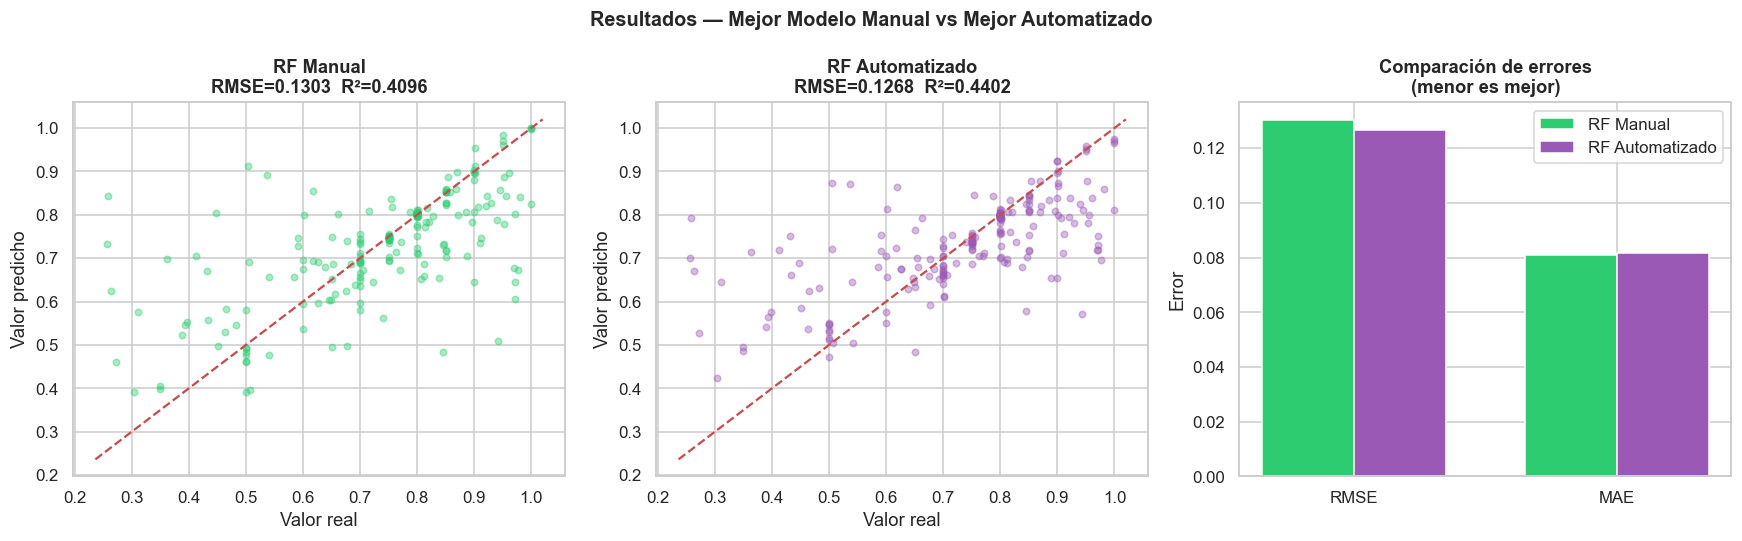

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
ax.scatter(y_test, y_pred_rf4, alpha=0.4, s=18, color='#2ecc71')
lim = [y_test.min()-0.02, y_test.max()+0.02]
ax.plot(lim, lim, 'r--', lw=1.5)
ax.set_xlabel('Valor real'); ax.set_ylabel('Valor predicho')
ax.set_title(f'RF Manual\nRMSE={rmse_man:.4f}  R²={r2_man:.4f}', fontweight='bold')
ax = axes[1]
ax.scatter(y_test, y_pred_best_auto, alpha=0.4, s=18, color='#9b59b6')
ax.plot(lim, lim, 'r--', lw=1.5)
ax.set_xlabel('Valor real'); ax.set_ylabel('Valor predicho')
ax.set_title(f'RF Automatizado\nRMSE={rmse_auto:.4f}  R²={r2_auto:.4f}', fontweight='bold')
ax = axes[2]
x = np.arange(2); width = 0.35
ax.bar(x-width/2, [rmse_man,mae_man], width, label='RF Manual', color='#2ecc71', edgecolor='white')
ax.bar(x+width/2, [rmse_auto,mae_auto], width, label='RF Automatizado', color='#9b59b6', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(['RMSE','MAE']); ax.set_ylabel('Error')
ax.set_title('Comparación de errores\n(menor es mejor)', fontweight='bold'); ax.legend()
plt.suptitle('Resultados — Mejor Modelo Manual vs Mejor Automatizado', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('comparacion_final.png', bbox_inches='tight'); plt.show()

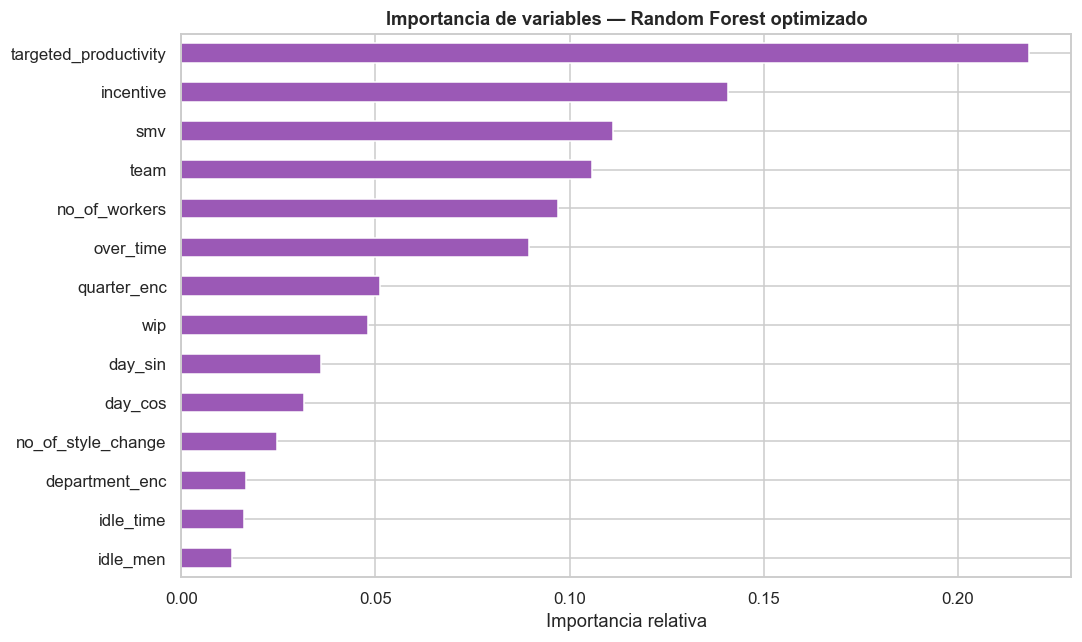

Variables más influyentes:
targeted_productivity    0.2183
incentive                0.1409
smv                      0.1112
team                     0.1058
no_of_workers            0.0970
over_time                0.0895


In [41]:
# Importancia de variables del modelo final (Random Forest optimizado)
feat_imp = pd.Series(best_rf.feature_importances_, index=ALL_FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Importancia de variables — Random Forest optimizado', fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout(); plt.savefig('importancia_variables.png', bbox_inches='tight'); plt.show()
print('Variables más influyentes:')
print(feat_imp.sort_values(ascending=False).head(6).round(4).to_string())

**Síntesis de resultados**

- Los **modelos basados en árboles** (Bagging y Random Forest) superaron de forma
  consistente a la regresión lineal y a KNN en todas las iteraciones, confirmando que
  las relaciones del dataset son **predominantemente no lineales**.
- El **mejor modelo** es un **Random Forest**. La optimización automática por
  GridSearchCV mejora sólo marginalmente el error respecto al Random Forest por defecto,
  pero reduce la varianza del error en validación cruzada (modelo más **robusto**).
- La variable más influyente para predecir la productividad real es, de manera coherente
  con el PCA, **`targeted_productivity`** (la meta asignada), seguida por variables
  operativas como `incentive`, `smv` y `wip`.

<a id="8"></a>
## 8. Conclusiones

- **Problema y enfoque.** Se abordó la predicción de la productividad real de equipos de
  una fábrica textil como un problema de regresión supervisada, recorriendo todo el
  pipeline de análisis de datos: obtención, EDA, pretratamiento, reducción de
  dimensionalidad (PCA) y modelado predictivo.

- **Calidad de los datos.** El EDA reveló faltantes con causas diversas (estructurales,
  derivables, errores de registro y "posible cero") e inconsistencias claras (typo
  `sweing`/`sewing`, texto en `team`, outliers imposibles en `smv` y `over_time`). El
  pretratamiento corrigió, imputó por mediana de grupo o por 0 según el caso, y eliminó
  filas sin valor objetivo, perdiendo una fracción mínima del dataset.

- **Estructura (PCA).** La varianza está repartida en muchas componentes (PC1+PC2 ≈ un
  tercio del total), señal de un fenómeno multidimensional. El PCA mostró agrupamientos
  por escala operativa y correlaciones interpretables (WIP–horas extra–N° operarios;
  prod. real–prod. objetivo), que orientaron la selección de variables del modelo.

- **Modelo predictivo.** El **Random Forest** fue el mejor modelo, superando a los
  lineales y a KNN. GridSearchCV aportó robustez más que una gran mejora de error,
  indicando que el ensemble por defecto ya capturaba bien la señal disponible.

- **Limitaciones e interpretación.** El R² alcanzado es moderado: la productividad
  laboral depende de factores humanos y contextuales (motivación, fatiga, clima laboral)
  difíciles de capturar en variables numéricas. Aun así, el modelo es **útil para
  identificar tendencias y los factores más influyentes** —encabezados por la meta de
  productividad y los incentivos— y para señalar tempranamente equipos con riesgo de no
  cumplir su objetivo.

- **Trabajo futuro.** Incorporar variables de contexto (ausentismo, antigüedad,
  condiciones del turno), probar modelos de *gradient boosting* y enriquecer la
  ingeniería de atributos temporales podría mejorar la capacidad predictiva.
